# VisDrone Tracking-by-Detection Pipeline

## 1. Title and Overview

This notebook documents an end-to-end aerial vision pipeline for object detection and multi-object tracking on VisDrone.
The system first predicts frame-level objects with Faster R-CNN (ResNet-50 FPN), then links detections across time with a ByteTrack-style IoU tracker.
The objective is not only to run the pipeline, but to make each design decision, trade-off, and evaluation result explicit for technical review.
All stages are artifact-driven to support reproducibility, metric validation, and evaluator-friendly auditing.

Pipeline flow in this notebook:
- VisDrone annotation conversion to COCO format
- Detector training on DET-train
- Detection evaluation on DET-val
- MOT inference and trajectory generation on MOT-val
- Tracking evaluation and visualization analysis

Transition: the next section defines the problem context and dataset constraints that motivate this design.

## 2. Problem Statement

VisDrone contains dense urban aerial scenes with small objects, frequent occlusions, camera motion, and perspective variation.
These properties make both localization and identity continuity difficult, so detection and tracking errors compound across stages.
The core task is to build a practical tracking-by-detection system that is reproducible, explainable, and quantitatively verifiable.

## 3. Dataset Description

This notebook uses the official VisDrone 2019 splits:
- DET-train: detector optimization
- DET-val: detector validation and COCO-style reporting
- MOT-val: sequence-level tracking inference and MOT metric evaluation
- Object taxonomy: 10 transportation and pedestrian-related classes used consistently in conversion, training, and tracking

> Insight: aerial viewpoints compress object scale, so detector recall on small objects is a critical bottleneck for downstream tracking continuity.

## 4. Pipeline Architecture

The implementation follows a staged architecture:
1. Validate and resolve dataset roots and artifact directories
2. Convert VisDrone DET annotations to COCO JSON
3. Build PyTorch data loaders and train Faster R-CNN
4. Evaluate detection quality with mAP, mAR, precision, and recall
5. Run MOT inference and ByteTrack-style association
6. Evaluate tracking with MOTA, HOTA, IDSW, precision, and recall
7. Generate diagnostic visualizations and final publication artifacts

### Design Choices and Rationale

- Why Faster R-CNN: two-stage proposals provide strong localization under clutter and overlap, which is important for small aerial targets.
- Why ByteTrack-style IoU tracking: confidence-aware IoU association is efficient, transparent, and easy to audit in a reproducible notebook setting.
- Why no ReID model: the pipeline intentionally isolates detector-driven tracking behavior, reducing complexity and keeping failure modes interpretable.
- Why these thresholds: detector confidence (0.30), MOT confidence (0.50), association minimum score (0.40), and tracker thresholds (high 0.6, low 0.2, match 0.7) balance recall preservation against false positives and unstable track births.

Transition: with the problem and architecture defined, the next cells establish reproducible runtime controls used by all subsequent stages.

In [2]:
# Run marker

In [3]:
# Environment setup (Kaggle-compatible, no Colab dependency).
# !pip install -q -r requirements.txt

import os

IN_KAGGLE = os.path.exists('/kaggle/input') and os.path.exists('/kaggle/working')
print('Running on Kaggle.' if IN_KAGGLE else 'Running outside Kaggle.')

Running on Kaggle.


### Runtime Setup and Reproducibility Controls

This setup section fixes seeds, resolves execution environment details, and defines stage-aware runtime controls.
It also centralizes thresholds and optimization hyperparameters so downstream behavior can be interpreted against known settings.
A stable setup is necessary for fair comparison across runs and for consistent artifact validation during evaluation.

Transition: after initialization, the notebook inlines the implementation modules used in data processing, modeling, tracking, and evaluation.

In [4]:
import json
import math
import random
import shutil
import sys
import time
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
from PIL import Image
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
from torchvision.transforms import functional as F
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)
print('CUDA available:', torch.cuda.is_available())

Using device: cuda
CUDA available: True


In [5]:
# Clean environment and GPU readiness
import gc
import torch

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('Clean environment ready')
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Clean environment ready
GPU: Tesla T4


In [6]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [42]:
# Pipeline execution controls.
# STAGE options: ALL, CONVERT, TRAIN, DET_EVAL, MOT_INFER, TRACK_EVAL, ANALYZE
PIPELINE_STAGE = 'ALL'
AUTO_INCLUDE_PREREQUISITES = True

# Performance modes for safe development and full submission runs.
# MODE options: 'fast' or 'full'
MODE = 'full'
if MODE not in {'fast', 'full'}:
    raise ValueError("MODE must be either 'fast' or 'full'.")

FAST_DEV_RUN = False

# Kaggle dataset paths (auto-detect VisDrone root inside nested /kaggle/input folders).
BASE_DIR = Path('/kaggle/working')
INPUT_ROOT = Path('/kaggle/input')

print('Scanning /kaggle/input...')

def find_visdrone_root(base: Path) -> Optional[Path]:
    for p in base.rglob('*'):
        if (
            (p / 'VisDrone2019-DET-train').exists()
            and (p / 'VisDrone2019-DET-val').exists()
            and (p / 'VisDrone2019-MOT-val').exists()
        ):
            return p
    return None

if not INPUT_ROOT.exists():
    raise FileNotFoundError(f'Input root not found: {INPUT_ROOT}')

DATA_ROOT = find_visdrone_root(INPUT_ROOT)

if DATA_ROOT is None:
    raise FileNotFoundError('Could not locate VisDrone dataset inside /kaggle/input')

print('Resolved DATA_ROOT:', DATA_ROOT)

# Local copy logic is disabled for Kaggle (working storage is already local).
USE_LOCAL_COPY = False

DET_TRAIN_DIR = DATA_ROOT / 'VisDrone2019-DET-train'
DET_VAL_DIR = DATA_ROOT / 'VisDrone2019-DET-val'

def resolve_dataset_root(path: Path) -> Path:
    current = path
    for _ in range(5):
        if (current / 'images').exists() and (current / 'annotations').exists():
            return current
        if not current.exists() or not current.is_dir():
            break
        subdirs = [d for d in current.iterdir() if d.is_dir()]
        if len(subdirs) == 1:
            current = subdirs[0]
        else:
            break
    return current

def resolve_mot_root(path: Path) -> Path:
    current = path
    for _ in range(6):
        if (current / 'sequences').exists():
            return current
        if not current.exists() or not current.is_dir():
            break
        subdirs = [d for d in current.iterdir() if d.is_dir()]
        if len(subdirs) == 1:
            current = subdirs[0]
        else:
            break
    return current

DET_TRAIN_DIR = resolve_dataset_root(DET_TRAIN_DIR)
DET_VAL_DIR = resolve_dataset_root(DET_VAL_DIR)
MOT_VAL_DIR = resolve_mot_root(DATA_ROOT / 'VisDrone2019-MOT-val')

print('Resolved MOT path:', MOT_VAL_DIR)
assert (MOT_VAL_DIR / 'sequences').exists(), 'MOT sequences not found'

print('FINAL PATHS:')
print(DET_TRAIN_DIR)
print(DET_VAL_DIR)
print(MOT_VAL_DIR)

assert (DET_TRAIN_DIR / 'images').exists(), 'Train images not found'
assert (DET_TRAIN_DIR / 'annotations').exists(), 'Train annotations not found'

# Logging and progress control.
LOG_EVERY = 100

# Runtime profile.
EPOCHS = 4
BATCH_SIZE = 2
MAX_FRAMES = 400

# Optimizer stability controls.
LR = 0.005
SCHEDULER_STEP_SIZE = 3
SCHEDULER_GAMMA = 0.1
GRAD_CLIP_NORM = 5.0

# Core thresholds.
NUM_WORKERS = 2
DET_SCORE_THRESH = 0.30
MOT_SCORE_THRESH = 0.50
TRACK_ASSOC_MIN_SCORE = 0.40

# Inference and visualization controls.
MODEL_DETECTIONS_PER_IMG = 100
DET_TOPK_PER_IMAGE = 30
TRACK_VIS_MAX_BOXES = 20
NUM_DET_SAMPLES = 3
NUM_TRACK_SAMPLES = 3
PLOT_DET_COUNT_HISTOGRAM = True
HISTOGRAM_MAX_IMAGES = 120
REPORT_DPI = 220

# Persist all outputs to Kaggle working artifacts.
ARTIFACTS_DIR = BASE_DIR / 'artifacts'
COCO_DIR = ARTIFACTS_DIR / 'coco'
DETECTOR_DIR = ARTIFACTS_DIR / 'detector'
MOT_OUT_DIR = ARTIFACTS_DIR / 'mot'
REPORTS_DIR = ARTIFACTS_DIR / 'reports'

for p in [ARTIFACTS_DIR, COCO_DIR, DETECTOR_DIR, MOT_OUT_DIR, MOT_OUT_DIR / 'detections', MOT_OUT_DIR / 'tracks', REPORTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('BASE_DIR:', BASE_DIR)
print('DATA_ROOT:', DATA_ROOT)
print('Pipeline stage:', PIPELINE_STAGE)
print('Auto prerequisites:', AUTO_INCLUDE_PREREQUISITES)
print('MODE:', MODE)
print('FAST_DEV_RUN:', FAST_DEV_RUN)
print('EPOCHS:', EPOCHS)
print('BATCH_SIZE:', BATCH_SIZE)
print('MAX_FRAMES:', MAX_FRAMES)
print('Learning rate:', LR)
print('Scheduler StepLR:', {'step_size': SCHEDULER_STEP_SIZE, 'gamma': SCHEDULER_GAMMA})
print('Gradient clip norm:', GRAD_CLIP_NORM)
print('Detection threshold:', DET_SCORE_THRESH)
print('Tracking threshold:', MOT_SCORE_THRESH)
print('Association min score:', TRACK_ASSOC_MIN_SCORE)
print('USE_LOCAL_COPY:', USE_LOCAL_COPY)
print('Artifacts root:', ARTIFACTS_DIR)
print('Reports dir:', REPORTS_DIR)
print('Running optimized config:')
print('EPOCHS:', EPOCHS)
print('MODE:', MODE)

Scanning /kaggle/input...
Resolved DATA_ROOT: /kaggle/input/datasets/jatinkumar3110/iisc-assignment
Resolved MOT path: /kaggle/input/datasets/jatinkumar3110/iisc-assignment/VisDrone2019-MOT-val/VisDrone2019-MOT-val/VisDrone2019-MOT-val
FINAL PATHS:
/kaggle/input/datasets/jatinkumar3110/iisc-assignment/VisDrone2019-DET-train/VisDrone2019-DET-train/VisDrone2019-DET-train
/kaggle/input/datasets/jatinkumar3110/iisc-assignment/VisDrone2019-DET-val/VisDrone2019-DET-val/VisDrone2019-DET-val
/kaggle/input/datasets/jatinkumar3110/iisc-assignment/VisDrone2019-MOT-val/VisDrone2019-MOT-val/VisDrone2019-MOT-val
BASE_DIR: /kaggle/working
DATA_ROOT: /kaggle/input/datasets/jatinkumar3110/iisc-assignment
Pipeline stage: ALL
Auto prerequisites: True
MODE: full
FAST_DEV_RUN: False
EPOCHS: 4
BATCH_SIZE: 2
MAX_FRAMES: 400
Learning rate: 0.005
Scheduler StepLR: {'step_size': 3, 'gamma': 0.1}
Gradient clip norm: 5.0
Detection threshold: 0.3
Tracking threshold: 0.5
Association min score: 0.4
USE_LOCAL_COPY: F

In [8]:
# Configuration safety checks before full run
assert MODE == 'full', f"Expected MODE='full', got {MODE}"
assert PIPELINE_STAGE == 'ALL', f"Expected PIPELINE_STAGE='ALL', got {PIPELINE_STAGE}"
assert USE_LOCAL_COPY is False, f"Expected USE_LOCAL_COPY=False for Kaggle, got {USE_LOCAL_COPY}"
assert FAST_DEV_RUN is False, f"Expected FAST_DEV_RUN=False, got {FAST_DEV_RUN}"
assert EPOCHS == 4, f"Expected EPOCHS=4 for optimized run, got {EPOCHS}"
assert BATCH_SIZE == 2, f"Expected BATCH_SIZE=2, got {BATCH_SIZE}"
assert MAX_FRAMES == 400, f"Expected MAX_FRAMES=400, got {MAX_FRAMES}"

if not torch.cuda.is_available():
    raise RuntimeError('CUDA GPU is required. Please enable a Kaggle GPU runtime (T4/P100).')
gpu_name = torch.cuda.get_device_name(0)
assert any(tag in gpu_name for tag in ('T4', 'P100')), f"Expected T4 or P100 GPU, got {gpu_name}"
print('GPU check passed:', gpu_name)

print('Configuration checks passed')
print('MODE:', MODE)
print('PIPELINE_STAGE:', PIPELINE_STAGE)
print('USE_LOCAL_COPY:', USE_LOCAL_COPY)
print('FAST_DEV_RUN:', FAST_DEV_RUN)
print('EPOCHS:', EPOCHS)
print('BATCH_SIZE:', BATCH_SIZE)
print('MAX_FRAMES:', MAX_FRAMES)

GPU check passed: Tesla T4
Configuration checks passed
MODE: full
PIPELINE_STAGE: ALL
USE_LOCAL_COPY: False
FAST_DEV_RUN: False
EPOCHS: 4
BATCH_SIZE: 2
MAX_FRAMES: 400


### Pipeline Modules and Notebook Organization

This notebook is intentionally self-contained: dataset logic, preprocessing, detector utilities, tracking, and evaluation are all defined inline.
Keeping the full implementation in one document reduces environment mismatch during grading and makes code-to-result traceability straightforward.
The module order below mirrors the execution order used in the pipeline runner.

Included modules:
- Dataset
- Preprocessing
- Detector
- Tracking
- Tracking evaluation

Transition: the next section begins data preprocessing, starting with dataset path validation and split resolution.

In [9]:
# ## Dataset
from dataclasses import dataclass
from typing import Callable, DefaultDict, Iterable, Sequence

from torch.utils.data import Dataset

try:
    from pycocotools.coco import COCO
except ImportError as exc:
    raise ImportError('pycocotools is required for VisDroneDataset.') from exc

try:
    from pycocotools.cocoeval import COCOeval
except ImportError as exc:
    raise ImportError('pycocotools is required for COCO evaluation.') from exc

try:
    from scipy.optimize import linear_sum_assignment
except ImportError:
    linear_sum_assignment = None

from torchvision.models.detection import (
    FasterRCNN_ResNet50_FPN_Weights,
    fasterrcnn_resnet50_fpn,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


class VisDroneDataset(Dataset):
    """PyTorch dataset that loads images and COCO-format VisDrone annotations."""

    def __init__(
        self,
        images_dir: str,
        annotation_json: str,
        transforms: Optional[Callable[[Image.Image, Dict[str, torch.Tensor]], Tuple[torch.Tensor, Dict[str, torch.Tensor]]]] = None,
    ) -> None:
        self.images_dir = Path(images_dir)
        if not self.images_dir.exists():
            raise FileNotFoundError(f'Images directory does not exist: {self.images_dir}')

        self.coco = COCO(annotation_json)
        self.image_ids = sorted(self.coco.getImgIds())
        self.transforms = transforms

    def __len__(self) -> int:
        return len(self.image_ids)

    def __getitem__(self, index: int):
        image_id = self.image_ids[index]
        image_info = self.coco.loadImgs([image_id])[0]
        image_path = self.images_dir / image_info['file_name']
        if not image_path.exists():
            raise FileNotFoundError(f'Image file missing for id={image_id}: {image_path}')

        image = Image.open(image_path).convert('RGB')

        ann_ids = self.coco.getAnnIds(imgIds=[image_id])
        anns = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []
        area = []
        iscrowd = []

        for ann in anns:
            x, y, w, h = ann['bbox']
            if w <= 0 or h <= 0:
                continue

            x1 = float(x)
            y1 = float(y)
            x2 = x1 + float(w)
            y2 = y1 + float(h)
            if x2 <= x1 or y2 <= y1:
                continue

            boxes.append([x1, y1, x2, y2])
            labels.append(int(ann['category_id']))
            area.append(float(ann.get('area', w * h)))
            iscrowd.append(int(ann.get('iscrowd', 0)))

        if boxes:
            boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
            labels_tensor = torch.tensor(labels, dtype=torch.int64)
            area_tensor = torch.tensor(area, dtype=torch.float32)
            iscrowd_tensor = torch.tensor(iscrowd, dtype=torch.int64)
        else:
            boxes_tensor = torch.zeros((0, 4), dtype=torch.float32)
            labels_tensor = torch.zeros((0,), dtype=torch.int64)
            area_tensor = torch.zeros((0,), dtype=torch.float32)
            iscrowd_tensor = torch.zeros((0,), dtype=torch.int64)

        target = {
            'boxes': boxes_tensor,
            'labels': labels_tensor,
            'image_id': torch.tensor([image_id], dtype=torch.int64),
            'area': area_tensor,
            'iscrowd': iscrowd_tensor,
        }

        if self.transforms is not None:
            image, target = self.transforms(image, target)
        else:
            image = F.to_tensor(image)

        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))

In [10]:
# ## Preprocessing
VISDRONE_CATEGORIES = [
    {'id': 1, 'name': 'pedestrian'},
    {'id': 2, 'name': 'people'},
    {'id': 3, 'name': 'bicycle'},
    {'id': 4, 'name': 'car'},
    {'id': 5, 'name': 'van'},
    {'id': 6, 'name': 'truck'},
    {'id': 7, 'name': 'tricycle'},
    {'id': 8, 'name': 'awning-tricycle'},
    {'id': 9, 'name': 'bus'},
    {'id': 10, 'name': 'motor'},
]


class ConversionError(RuntimeError):
    pass


def _resolve_visdrone_root(dataset_dir: str, required_subdirs: Iterable[str]) -> Path:
    """Resolve a VisDrone split root even if the folder is nested one level deeper."""
    dataset_path = Path(dataset_dir)
    if not dataset_path.exists():
        raise FileNotFoundError(f'Dataset directory not found: {dataset_path}')

    required_subdirs = tuple(required_subdirs)

    def has_required(path: Path) -> bool:
        return all((path / subdir).exists() for subdir in required_subdirs)

    if has_required(dataset_path):
        return dataset_path

    nested = dataset_path / dataset_path.name
    if nested.exists() and has_required(nested):
        return nested

    candidates = [child for child in dataset_path.iterdir() if child.is_dir() and has_required(child)]
    if len(candidates) == 1:
        return candidates[0]

    required_txt = ', '.join(required_subdirs)
    raise ConversionError(
        f'Could not resolve VisDrone root under {dataset_path}. '
        f'Expected subfolders: {required_txt}.'
    )


def _list_images_conversion(images_dir: Path) -> List[Path]:
    valid_ext = {'.jpg', '.jpeg', '.png', '.bmp'}
    return sorted(path for path in images_dir.iterdir() if path.suffix.lower() in valid_ext)


def _parse_visdrone_line(line: str) -> Tuple[float, float, float, float, int, int, int]:
    parts = [token.strip() for token in line.split(',')]
    if len(parts) < 8:
        raise ValueError('Invalid VisDrone annotation line (expected at least 8 fields)')

    x = float(parts[0])
    y = float(parts[1])
    w = float(parts[2])
    h = float(parts[3])
    score = int(float(parts[4]))
    cls = int(float(parts[5]))
    truncation = int(float(parts[6]))
    occlusion = int(float(parts[7]))
    return x, y, w, h, score, cls, truncation, occlusion


def _clamp_bbox(x: float, y: float, w: float, h: float, image_w: int, image_h: int) -> Tuple[float, float, float, float]:
    x1 = max(0.0, x)
    y1 = max(0.0, y)
    x2 = min(float(image_w), x + w)
    y2 = min(float(image_h), y + h)
    return x1, y1, max(0.0, x2 - x1), max(0.0, y2 - y1)


def _convert_split(split_dir: Path, output_json: Path) -> Dict[str, int]:
    images_dir = split_dir / 'images'
    annotations_dir = split_dir / 'annotations'

    image_files = _list_images_conversion(images_dir)
    if not image_files:
        raise ConversionError(f'No images found in {images_dir}')

    coco = {
        'images': [],
        'annotations': [],
        'categories': VISDRONE_CATEGORIES,
    }

    image_id_map: Dict[str, int] = {}
    annotation_id = 1
    ignored_missing_ann = 0
    ignored_invalid_bbox = 0
    ignored_class_or_region = 0

    for image_id, image_path in enumerate(image_files, start=1):
        image_name = image_path.name
        stem = image_path.stem

        with Image.open(image_path) as image:
            width, height = image.size

        coco['images'].append(
            {
                'id': image_id,
                'file_name': image_name,
                'width': width,
                'height': height,
            }
        )
        image_id_map[stem] = image_id

        ann_path = annotations_dir / f'{stem}.txt'
        if not ann_path.exists():
            ignored_missing_ann += 1
            continue

        for raw_line in ann_path.read_text(encoding='utf-8').splitlines():
            if not raw_line.strip():
                continue

            try:
                x, y, w, h, _, cls, truncation, occlusion = _parse_visdrone_line(raw_line)
            except ValueError:
                ignored_invalid_bbox += 1
                continue

            # Ignore regions (class 0) and keep only classes 1..10.
            if cls == 0 or not (1 <= cls <= 10):
                ignored_class_or_region += 1
                continue

            if w <= 0 or h <= 0:
                ignored_invalid_bbox += 1
                continue

            x, y, w, h = _clamp_bbox(x, y, w, h, width, height)
            if w <= 0 or h <= 0:
                ignored_invalid_bbox += 1
                continue

            coco['annotations'].append(
                {
                    'id': annotation_id,
                    'image_id': image_id,
                    'category_id': cls,
                    'bbox': [x, y, w, h],
                    'area': w * h,
                    'iscrowd': 0,
                    'truncation': truncation,
                    'occlusion': occlusion,
                }
            )
            annotation_id += 1

    output_json.parent.mkdir(parents=True, exist_ok=True)
    output_json.write_text(json.dumps(coco), encoding='utf-8')

    return {
        'images': len(coco['images']),
        'annotations': len(coco['annotations']),
        'missing_annotation_files': ignored_missing_ann,
        'ignored_invalid_bbox': ignored_invalid_bbox,
        'ignored_class_or_region': ignored_class_or_region,
    }


def convert_visdrone_to_coco(
    det_train_dir: str,
    det_val_dir: str,
    output_dir: str,
) -> Dict[str, Dict[str, int]]:
    """Convert VisDrone DET train/val annotations to COCO JSON files.

    Returns a dictionary with summary counts for train and val splits.
    """
    output_path = Path(output_dir)

    train_root = _resolve_visdrone_root(det_train_dir, required_subdirs=('images', 'annotations'))
    val_root = _resolve_visdrone_root(det_val_dir, required_subdirs=('images', 'annotations'))

    train_json = output_path / 'train.json'
    val_json = output_path / 'val.json'

    train_stats = _convert_split(train_root, train_json)
    val_stats = _convert_split(val_root, val_json)

    return {
        'train': train_stats,
        'val': val_stats,
        'train_json': {'path': str(train_json)},
        'val_json': {'path': str(val_json)},
    }


def resolve_visdrone_root(dataset_dir: str, required_subdirs: Iterable[str]) -> Path:
    """Public wrapper to reuse robust root resolution in other modules."""
    return _resolve_visdrone_root(dataset_dir, required_subdirs=required_subdirs)

In [11]:
# ## Detector
def get_model(num_object_classes: int = 10, pretrained: bool = True) -> torch.nn.Module:
    """Build Faster R-CNN with a class head for VisDrone classes (1..10)."""
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT if pretrained else None
    model = fasterrcnn_resnet50_fpn(weights=weights)
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # torchvision includes background as class 0.
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_object_classes + 1)
    return model


def train_one_epoch(
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    data_loader: DataLoader,
    device: torch.device,
    epoch: int,
    print_freq: int = 20,
) -> float:
    model.train()
    running_loss = 0.0

    for step, (images, targets) in enumerate(data_loader, start=1):
        images = [image.to(device) for image in images]
        targets = [{key: value.to(device) for key, value in target.items()} for target in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        loss_value = float(losses.item())

        if not math.isfinite(loss_value):
            print(f'[Epoch {epoch}] Non-finite loss at step {step}: {loss_value:.5f}. Skipping.')
            continue

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_loss += loss_value

        if step % print_freq == 0:
            loss_log = ', '.join(f'{name}: {value.item():.4f}' for name, value in loss_dict.items())
            print(f'[Epoch {epoch}] step={step}/{len(data_loader)} total_loss={loss_value:.4f} ({loss_log})')

    avg_loss = running_loss / max(1, len(data_loader))
    print(f'[Epoch {epoch}] average_loss={avg_loss:.4f}')
    return avg_loss


def _to_coco_results(
    outputs: Iterable[Dict[str, torch.Tensor]],
    targets: Iterable[Dict[str, torch.Tensor]],
    score_thresh: float,
) -> List[Dict[str, object]]:
    coco_results: List[Dict[str, object]] = []

    for target, output in zip(targets, outputs):
        image_id = int(target['image_id'].item())
        boxes = output['boxes'].detach().cpu()
        scores = output['scores'].detach().cpu()
        labels = output['labels'].detach().cpu()

        for box, score, label in zip(boxes, scores, labels):
            score_value = float(score.item())
            if score_value < score_thresh:
                continue

            x1, y1, x2, y2 = [float(v) for v in box.tolist()]
            width = max(0.0, x2 - x1)
            height = max(0.0, y2 - y1)
            if width <= 0 or height <= 0:
                continue

            coco_results.append(
                {
                    'image_id': image_id,
                    'category_id': int(label.item()),
                    'bbox': [x1, y1, width, height],
                    'score': score_value,
                }
            )

    return coco_results


def evaluate_detector(
    model: torch.nn.Module,
    data_loader: DataLoader,
    device: torch.device,
    score_thresh: float = 0.05,
    coco_gt=None,
) -> Dict[str, float]:
    model.eval()

    if coco_gt is None:
        if not hasattr(data_loader.dataset, 'coco'):
            raise ValueError('Dataset must expose COCO ground truth as dataset.coco')
        coco_gt = data_loader.dataset.coco

    predictions: List[Dict[str, object]] = []

    with torch.no_grad():
        for images, targets in data_loader:
            images = [image.to(device) for image in images]
            outputs = model(images)
            predictions.extend(_to_coco_results(outputs, targets, score_thresh=score_thresh))

    if not predictions:
        print('No predictions above threshold; returning zero metrics.')
        return {
            'mAP@0.50:0.95': 0.0,
            'mAP@0.50': 0.0,
            'mAR@0.50': 0.0,
            'mAR@0.50:0.95': 0.0,
            'mAR@max=1': 0.0,
            'mAR@max=10': 0.0,
            'mAR@max=100': 0.0,
            'precision': 0.0,
            'recall': 0.0,
        }

    coco_dt = coco_gt.loadRes(predictions)
    evaluator = COCOeval(coco_gt, coco_dt, iouType='bbox')
    evaluator.evaluate()
    evaluator.accumulate()
    evaluator.summarize()

    precision = evaluator.eval['precision'][:, :, :, 0, 2]
    precision = precision[precision > -1]
    mean_precision = float(precision.mean()) if precision.size > 0 else 0.0

    recall = evaluator.eval['recall'][:, :, 0, 2]
    recall = recall[recall > -1]
    mean_recall = float(recall.mean()) if recall.size > 0 else 0.0

    iou_thresholds = list(evaluator.params.iouThrs)
    idx_iou50 = min(range(len(iou_thresholds)), key=lambda idx: abs(float(iou_thresholds[idx]) - 0.5))
    recall_iou50 = evaluator.eval['recall'][idx_iou50, :, 0, 2]
    recall_iou50 = recall_iou50[recall_iou50 > -1]
    mean_recall_iou50 = float(recall_iou50.mean()) if recall_iou50.size > 0 else 0.0

    metrics = {
        'mAP@0.50:0.95': float(evaluator.stats[0]),
        'mAP@0.50': float(evaluator.stats[1]),
        'mAR@0.50': mean_recall_iou50,
        'mAR@0.50:0.95': float(evaluator.stats[8]),
        'mAR@max=1': float(evaluator.stats[6]),
        'mAR@max=10': float(evaluator.stats[7]),
        'mAR@max=100': float(evaluator.stats[8]),
        'precision': mean_precision,
        'recall': mean_recall,
    }

    print(
        'Detector metrics: '
        f"mAP@0.50:0.95={metrics['mAP@0.50:0.95']:.4f}, "
        f"mAP@0.50={metrics['mAP@0.50']:.4f}, "
        f"mAR@0.50={metrics['mAR@0.50']:.4f}, "
        f"mAR@0.50:0.95={metrics['mAR@0.50:0.95']:.4f}, "
        f"precision={metrics['precision']:.4f}, recall={metrics['recall']:.4f}"
    )
    return metrics


def save_checkpoint(
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    output_dir: str,
) -> Path:
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    checkpoint_path = output_path / f'detector_epoch_{epoch:03d}.pth'
    torch.save(
        {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
        },
        checkpoint_path,
    )
    return checkpoint_path


def load_checkpoint(model: torch.nn.Module, checkpoint_path: str, device: torch.device) -> Dict[str, object]:
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    return checkpoint


In [12]:
# ## Tracking
@dataclass
class ByteTrackParams:
    high_thresh: float = 0.5
    low_thresh: float = 0.1
    match_thresh: float = 0.5
    new_track_thresh: float = 0.6
    max_time_lost: int = 30
    min_hits: int = 3


class ByteTrackTracker:
    """Explainable ByteTrack-style tracker based on IoU matching."""

    def __init__(self, params: Optional[ByteTrackParams] = None) -> None:
        self.params = params or ByteTrackParams()
        self.tracks: List[Dict[str, object]] = []
        self.next_track_id = 1
        self.frame_id = 0

    def reset(self) -> None:
        self.tracks.clear()
        self.next_track_id = 1
        self.frame_id = 0

    def update(self, detections: Sequence[Dict[str, object]], frame_id: Optional[int] = None) -> List[Dict[str, object]]:
        if frame_id is None:
            self.frame_id += 1
        else:
            self.frame_id = frame_id

        high_dets = [det for det in detections if float(det['score']) >= self.params.high_thresh]
        low_dets = [det for det in detections if self.params.low_thresh <= float(det['score']) < self.params.high_thresh]

        for track in self.tracks:
            track['age'] = int(track['age']) + 1
            track['time_since_update'] = int(track['time_since_update']) + 1

        first_matches, unmatched_track_indices, unmatched_high_indices = _associate(
            self.tracks,
            high_dets,
            match_thresh=self.params.match_thresh,
        )
        self._apply_matches(first_matches, high_dets)

        remaining_tracks = [self.tracks[index] for index in unmatched_track_indices]
        second_matches_local, remaining_unmatched_track_local, _ = _associate(
            remaining_tracks,
            low_dets,
            match_thresh=self.params.match_thresh,
        )

        second_matches = [(unmatched_track_indices[t_idx], d_idx) for t_idx, d_idx in second_matches_local]
        self._apply_matches(second_matches, low_dets)

        unmatched_after_second = [unmatched_track_indices[idx] for idx in remaining_unmatched_track_local]
        self._prune_lost_tracks(unmatched_after_second)

        for det_index in unmatched_high_indices:
            det = high_dets[det_index]
            if float(det['score']) < self.params.new_track_thresh:
                continue
            self._start_track(det)

        active_outputs = []
        for track in self.tracks:
            if int(track['time_since_update']) == 0:
                enough_hits = int(track['hits']) >= self.params.min_hits or self.frame_id <= self.params.min_hits
                if enough_hits:
                    active_outputs.append(
                        {
                            'frame': self.frame_id,
                            'track_id': int(track['track_id']),
                            'bbox': track['bbox'],
                            'score': float(track['score']),
                            'label': int(track['label']),
                        }
                    )

        return active_outputs

    def _apply_matches(self, matches: Sequence[Tuple[int, int]], detections: Sequence[Dict[str, object]]) -> None:
        for track_idx, det_idx in matches:
            detection = detections[det_idx]
            track = self.tracks[track_idx]
            track['bbox'] = np.asarray(detection['bbox'], dtype=np.float32)
            track['score'] = float(detection['score'])
            track['label'] = int(detection['label'])
            track['hits'] = int(track['hits']) + 1
            track['time_since_update'] = 0

    def _prune_lost_tracks(self, unmatched_track_indices: Sequence[int]) -> None:
        _ = unmatched_track_indices
        self.tracks = [
            track
            for track in self.tracks
            if int(track['time_since_update']) <= self.params.max_time_lost
        ]

    def _start_track(self, detection: Dict[str, object]) -> None:
        self.tracks.append(
            {
                'track_id': self.next_track_id,
                'bbox': np.asarray(detection['bbox'], dtype=np.float32),
                'score': float(detection['score']),
                'label': int(detection['label']),
                'hits': 1,
                'age': 1,
                'time_since_update': 0,
            }
        )
        self.next_track_id += 1


def _associate(
    tracks: Sequence[Dict[str, object]],
    detections: Sequence[Dict[str, object]],
    match_thresh: float,
) -> Tuple[List[Tuple[int, int]], List[int], List[int]]:
    if len(tracks) == 0:
        return [], [], list(range(len(detections)))
    if len(detections) == 0:
        return [], list(range(len(tracks))), []

    iou_matrix = _compute_iou_matrix(tracks, detections)
    cost_matrix = 1.0 - iou_matrix

    matches: List[Tuple[int, int]] = []
    unmatched_tracks = set(range(len(tracks)))
    unmatched_detections = set(range(len(detections)))

    if linear_sum_assignment is not None:
        row_indices, col_indices = linear_sum_assignment(cost_matrix)
        for track_idx, det_idx in zip(row_indices, col_indices):
            iou = iou_matrix[track_idx, det_idx]
            if iou < match_thresh:
                continue
            if int(tracks[track_idx]['label']) != int(detections[det_idx]['label']):
                continue
            matches.append((track_idx, det_idx))
            unmatched_tracks.discard(track_idx)
            unmatched_detections.discard(det_idx)
    else:
        # Greedy fallback if scipy is unavailable.
        while True:
            if iou_matrix.size == 0:
                break
            track_idx, det_idx = np.unravel_index(np.argmax(iou_matrix), iou_matrix.shape)
            best_iou = iou_matrix[track_idx, det_idx]
            if best_iou < match_thresh:
                break
            if int(tracks[track_idx]['label']) != int(detections[det_idx]['label']):
                iou_matrix[track_idx, det_idx] = -1.0
                continue
            matches.append((int(track_idx), int(det_idx)))
            unmatched_tracks.discard(int(track_idx))
            unmatched_detections.discard(int(det_idx))
            iou_matrix[track_idx, :] = -1.0
            iou_matrix[:, det_idx] = -1.0

    return matches, sorted(unmatched_tracks), sorted(unmatched_detections)


def _compute_iou_matrix(
    tracks: Sequence[Dict[str, object]],
    detections: Sequence[Dict[str, object]],
) -> np.ndarray:
    track_boxes = np.asarray([track['bbox'] for track in tracks], dtype=np.float32)
    det_boxes = np.asarray([det['bbox'] for det in detections], dtype=np.float32)

    if track_boxes.size == 0 or det_boxes.size == 0:
        return np.zeros((len(tracks), len(detections)), dtype=np.float32)

    x1 = np.maximum(track_boxes[:, None, 0], det_boxes[None, :, 0])
    y1 = np.maximum(track_boxes[:, None, 1], det_boxes[None, :, 1])
    x2 = np.minimum(track_boxes[:, None, 2], det_boxes[None, :, 2])
    y2 = np.minimum(track_boxes[:, None, 3], det_boxes[None, :, 3])

    inter_w = np.maximum(0.0, x2 - x1)
    inter_h = np.maximum(0.0, y2 - y1)
    intersection = inter_w * inter_h

    track_area = (track_boxes[:, 2] - track_boxes[:, 0]) * (track_boxes[:, 3] - track_boxes[:, 1])
    det_area = (det_boxes[:, 2] - det_boxes[:, 0]) * (det_boxes[:, 3] - det_boxes[:, 1])

    union = track_area[:, None] + det_area[None, :] - intersection
    union = np.maximum(union, 1e-6)

    return intersection / union


def bytetrack_update(
    tracker: ByteTrackTracker,
    detections: Sequence[Dict[str, object]],
    frame_id: Optional[int] = None,
) -> List[Dict[str, object]]:
    return tracker.update(detections=detections, frame_id=frame_id)


def run_inference_on_mot(
    model: torch.nn.Module,
    mot_root: str,
    device: torch.device,
    output_dir: Optional[str] = None,
    score_thresh: float = 0.3,
    max_frames: Optional[int] = None,
    tracker_params: Optional[ByteTrackParams] = None,
    use_tracking: bool = True,
) -> Dict[str, Dict[str, object]]:
    """Run detector frame-wise on MOT sequences and optionally produce track files."""
    model.eval()
    resolved_mot_root = resolve_visdrone_root(mot_root, required_subdirs=('sequences', 'annotations'))

    sequences_dir = resolved_mot_root / 'sequences'
    output_path = Path(output_dir) if output_dir is not None else None

    if output_path is not None:
        (output_path / 'detections').mkdir(parents=True, exist_ok=True)
        if use_tracking:
            (output_path / 'tracks').mkdir(parents=True, exist_ok=True)

    sequence_outputs: Dict[str, Dict[str, object]] = {}

    sequence_dirs = sorted(path for path in sequences_dir.iterdir() if path.is_dir())

    with torch.no_grad():
        for sequence_dir in sequence_dirs:
            sequence_name = sequence_dir.name
            frame_dir = sequence_dir / 'img1'
            if not frame_dir.exists():
                frame_dir = sequence_dir

            frame_paths = sorted(path for path in frame_dir.iterdir() if path.suffix.lower() in {'.jpg', '.jpeg', '.png'})
            if max_frames is not None:
                frame_paths = frame_paths[:max_frames]

            tracker = ByteTrackTracker(params=tracker_params) if use_tracking else None

            sequence_detections: Dict[int, List[Dict[str, object]]] = {}
            sequence_tracks: List[str] = []
            sequence_det_lines: List[str] = []

            for frame_path in frame_paths:
                frame_id = _parse_frame_id(frame_path.stem)

                image = Image.open(frame_path).convert('RGB')
                image_tensor = F.to_tensor(image).to(device)
                output = model([image_tensor])[0]

                detections = _extract_frame_detections(output, score_thresh=score_thresh)
                sequence_detections[frame_id] = detections

                for det in detections:
                    x1, y1, x2, y2 = [float(v) for v in det['bbox']]
                    w = max(0.0, x2 - x1)
                    h = max(0.0, y2 - y1)
                    sequence_det_lines.append(
                        f"{frame_id},-1,{x1:.2f},{y1:.2f},{w:.2f},{h:.2f},{float(det['score']):.6f},{int(det['label'])},-1,-1"
                    )

                if tracker is not None:
                    active_tracks = bytetrack_update(tracker, detections=detections, frame_id=frame_id)
                    for track in active_tracks:
                        x1, y1, x2, y2 = [float(v) for v in track['bbox']]
                        w = max(0.0, x2 - x1)
                        h = max(0.0, y2 - y1)
                        sequence_tracks.append(
                            f"{frame_id},{int(track['track_id'])},{x1:.2f},{y1:.2f},{w:.2f},{h:.2f},{float(track['score']):.6f},{int(track['label'])},-1,-1"
                        )

            sequence_outputs[sequence_name] = {
                'detections': sequence_detections,
                'num_frames': len(frame_paths),
                'num_detections': int(sum(len(frame_dets) for frame_dets in sequence_detections.values())),
                'num_tracks': len(sequence_tracks),
            }

            if output_path is not None:
                det_file = output_path / 'detections' / f'{sequence_name}.txt'
                det_file.write_text('\n'.join(sequence_det_lines), encoding='utf-8')

                if use_tracking:
                    track_file = output_path / 'tracks' / f'{sequence_name}.txt'
                    track_file.write_text('\n'.join(sequence_tracks), encoding='utf-8')

            print(
                f"[MOT inference] seq={sequence_name} frames={len(frame_paths)} "
                f"detections={sequence_outputs[sequence_name]['num_detections']}"
            )

    return sequence_outputs


def _extract_frame_detections(output: Dict[str, torch.Tensor], score_thresh: float) -> List[Dict[str, object]]:
    detections: List[Dict[str, object]] = []
    boxes = output['boxes'].detach().cpu().numpy()
    scores = output['scores'].detach().cpu().numpy()
    labels = output['labels'].detach().cpu().numpy()

    for box, score, label in zip(boxes, scores, labels):
        if float(score) < score_thresh:
            continue
        x1, y1, x2, y2 = [float(v) for v in box.tolist()]
        if x2 <= x1 or y2 <= y1:
            continue
        detections.append(
            {
                'bbox': [x1, y1, x2, y2],
                'score': float(score),
                'label': int(label),
            }
        )
    return detections


def _parse_frame_id(stem: str) -> int:
    if stem.isdigit():
        return int(stem)

    digits = ''.join(ch for ch in stem if ch.isdigit())
    if digits:
        return int(digits)

    raise ValueError(f'Cannot parse frame id from name: {stem}')


In [13]:
# ## Tracking Evaluation
def evaluate_tracking(
    gt_root: str,
    pred_dir: str,
    iou_threshold: float = 0.5,
    class_aware: bool = True,
) -> Dict[str, object]:
    """Evaluate tracking predictions with MOTA, HOTA, IDSW, precision and recall."""
    gt_annotations_dir = _resolve_gt_annotations_dir(gt_root)
    pred_path = Path(pred_dir)
    if not pred_path.exists():
        raise FileNotFoundError(f'Prediction directory not found: {pred_path}')

    gt_files = sorted(gt_annotations_dir.glob('*.txt'))
    if not gt_files:
        raise FileNotFoundError(f'No annotation files found under: {gt_annotations_dir}')

    per_sequence: Dict[str, Dict[str, float]] = {}

    global_tp = 0
    global_fp = 0
    global_fn = 0
    global_idsw = 0
    global_gt = 0

    global_pair_matches: DefaultDict[Tuple[str, int, int], int] = defaultdict(int)
    global_gt_matches: DefaultDict[Tuple[str, int], int] = defaultdict(int)
    global_pred_matches: DefaultDict[Tuple[str, int], int] = defaultdict(int)

    for gt_file in gt_files:
        sequence_name = gt_file.stem
        pred_file = pred_path / f'{sequence_name}.txt'

        gt_by_frame = _read_mot_file(gt_file, is_gt=True)
        pred_by_frame = _read_mot_file(pred_file, is_gt=False) if pred_file.exists() else defaultdict(list)

        tp, fp, fn, idsw, total_gt, pair_matches, gt_matches, pred_matches = _evaluate_sequence(
            sequence_name=sequence_name,
            gt_by_frame=gt_by_frame,
            pred_by_frame=pred_by_frame,
            iou_threshold=iou_threshold,
            class_aware=class_aware,
        )

        metrics = _compute_metrics(tp=tp, fp=fp, fn=fn, idsw=idsw, total_gt=total_gt, pair_matches=pair_matches, gt_matches=gt_matches, pred_matches=pred_matches)
        per_sequence[sequence_name] = metrics

        global_tp += tp
        global_fp += fp
        global_fn += fn
        global_idsw += idsw
        global_gt += total_gt

        for key, value in pair_matches.items():
            global_pair_matches[(sequence_name, key[0], key[1])] += value
        for key, value in gt_matches.items():
            global_gt_matches[(sequence_name, key)] += value
        for key, value in pred_matches.items():
            global_pred_matches[(sequence_name, key)] += value

    overall = _compute_metrics(
        tp=global_tp,
        fp=global_fp,
        fn=global_fn,
        idsw=global_idsw,
        total_gt=global_gt,
        pair_matches=global_pair_matches,
        gt_matches=global_gt_matches,
        pred_matches=global_pred_matches,
    )

    return {
        'overall': overall,
        'per_sequence': per_sequence,
    }


def _resolve_gt_annotations_dir(gt_root: str) -> Path:
    root_path = Path(gt_root)
    if not root_path.exists():
        raise FileNotFoundError(f'Ground-truth path not found: {root_path}')

    if (root_path / 'annotations').exists():
        return root_path / 'annotations'

    try:
        resolved = resolve_visdrone_root(gt_root, required_subdirs=('annotations', 'sequences'))
        return resolved / 'annotations'
    except Exception:
        pass

    if root_path.name == 'annotations':
        return root_path

    nested_annotations = root_path / root_path.name / 'annotations'
    if nested_annotations.exists():
        return nested_annotations

    raise FileNotFoundError(f'Could not locate annotations directory from: {root_path}')


def _read_mot_file(file_path: Path, is_gt: bool) -> DefaultDict[int, List[Dict[str, float]]]:
    records: DefaultDict[int, List[Dict[str, float]]] = defaultdict(list)
    if not file_path.exists():
        return records

    for line in file_path.read_text(encoding='utf-8').splitlines():
        line = line.strip()
        if not line:
            continue

        parts = [token.strip() for token in line.split(',')]
        if len(parts) < 6:
            continue

        frame = int(float(parts[0]))
        obj_id = int(float(parts[1]))
        x = float(parts[2])
        y = float(parts[3])
        w = float(parts[4])
        h = float(parts[5])

        if w <= 0 or h <= 0:
            continue

        score = float(parts[6]) if len(parts) > 6 else 1.0
        category = int(float(parts[7])) if len(parts) > 7 else -1

        if is_gt:
            if category == 0 or not (1 <= category <= 10):
                continue
            if score <= 0.0:
                continue

        bbox = np.array([x, y, x + w, y + h], dtype=np.float32)
        records[frame].append(
            {
                'id': obj_id,
                'bbox': bbox,
                'score': score,
                'label': category,
            }
        )

    return records


def _evaluate_sequence(
    sequence_name: str,
    gt_by_frame: DefaultDict[int, List[Dict[str, float]]],
    pred_by_frame: DefaultDict[int, List[Dict[str, float]]],
    iou_threshold: float,
    class_aware: bool,
):
    frames = sorted(set(gt_by_frame.keys()) | set(pred_by_frame.keys()))

    tp = 0
    fp = 0
    fn = 0
    idsw = 0
    total_gt = 0

    pair_matches: DefaultDict[Tuple[int, int], int] = defaultdict(int)
    gt_matches: DefaultDict[int, int] = defaultdict(int)
    pred_matches: DefaultDict[int, int] = defaultdict(int)

    prev_gt_to_pred: Dict[int, int] = {}
    prev_frame_for_gt: Dict[int, int] = {}

    for frame in frames:
        gt_objects = gt_by_frame.get(frame, [])
        pred_objects = pred_by_frame.get(frame, [])

        total_gt += len(gt_objects)

        matches, unmatched_gt, unmatched_pred = _match_objects(
            gt_objects,
            pred_objects,
            iou_threshold=iou_threshold,
            class_aware=class_aware,
        )

        tp += len(matches)
        fn += len(unmatched_gt)
        fp += len(unmatched_pred)

        for gt_index, pred_index in matches:
            gt_obj = gt_objects[gt_index]
            pred_obj = pred_objects[pred_index]

            gt_id = int(gt_obj['id'])
            pred_id = int(pred_obj['id'])

            if gt_id in prev_gt_to_pred:
                prev_pred_id = prev_gt_to_pred[gt_id]
                prev_frame = prev_frame_for_gt.get(gt_id, frame - 1)
                if prev_pred_id != pred_id and (frame - prev_frame) <= 1:
                    idsw += 1

            prev_gt_to_pred[gt_id] = pred_id
            prev_frame_for_gt[gt_id] = frame

            pair_matches[(gt_id, pred_id)] += 1
            gt_matches[gt_id] += 1
            pred_matches[pred_id] += 1

    _ = sequence_name
    return tp, fp, fn, idsw, total_gt, pair_matches, gt_matches, pred_matches


def _match_objects(
    gt_objects: Sequence[Dict[str, float]],
    pred_objects: Sequence[Dict[str, float]],
    iou_threshold: float,
    class_aware: bool,
):
    if len(gt_objects) == 0:
        return [], [], list(range(len(pred_objects)))
    if len(pred_objects) == 0:
        return [], list(range(len(gt_objects))), []

    iou_matrix = _pairwise_iou(gt_objects, pred_objects)

    if class_aware:
        for gt_idx, gt_obj in enumerate(gt_objects):
            for pred_idx, pred_obj in enumerate(pred_objects):
                gt_label = int(gt_obj.get('label', -1))
                pred_label = int(pred_obj.get('label', -1))
                if gt_label != -1 and pred_label != -1 and gt_label != pred_label:
                    iou_matrix[gt_idx, pred_idx] = 0.0

    matches: List[Tuple[int, int]] = []
    unmatched_gt = set(range(len(gt_objects)))
    unmatched_pred = set(range(len(pred_objects)))

    if linear_sum_assignment is not None:
        row_indices, col_indices = linear_sum_assignment(1.0 - iou_matrix)
        for gt_idx, pred_idx in zip(row_indices, col_indices):
            if iou_matrix[gt_idx, pred_idx] < iou_threshold:
                continue
            matches.append((int(gt_idx), int(pred_idx)))
            unmatched_gt.discard(int(gt_idx))
            unmatched_pred.discard(int(pred_idx))
    else:
        while True:
            if iou_matrix.size == 0:
                break
            gt_idx, pred_idx = np.unravel_index(np.argmax(iou_matrix), iou_matrix.shape)
            best_iou = iou_matrix[gt_idx, pred_idx]
            if best_iou < iou_threshold:
                break
            matches.append((int(gt_idx), int(pred_idx)))
            unmatched_gt.discard(int(gt_idx))
            unmatched_pred.discard(int(pred_idx))
            iou_matrix[gt_idx, :] = -1.0
            iou_matrix[:, pred_idx] = -1.0

    return matches, sorted(unmatched_gt), sorted(unmatched_pred)


def _pairwise_iou(gt_objects: Sequence[Dict[str, float]], pred_objects: Sequence[Dict[str, float]]) -> np.ndarray:
    gt_boxes = np.asarray([obj['bbox'] for obj in gt_objects], dtype=np.float32)
    pred_boxes = np.asarray([obj['bbox'] for obj in pred_objects], dtype=np.float32)

    x1 = np.maximum(gt_boxes[:, None, 0], pred_boxes[None, :, 0])
    y1 = np.maximum(gt_boxes[:, None, 1], pred_boxes[None, :, 1])
    x2 = np.minimum(gt_boxes[:, None, 2], pred_boxes[None, :, 2])
    y2 = np.minimum(gt_boxes[:, None, 3], pred_boxes[None, :, 3])

    inter_w = np.maximum(0.0, x2 - x1)
    inter_h = np.maximum(0.0, y2 - y1)
    inter_area = inter_w * inter_h

    gt_area = (gt_boxes[:, 2] - gt_boxes[:, 0]) * (gt_boxes[:, 3] - gt_boxes[:, 1])
    pred_area = (pred_boxes[:, 2] - pred_boxes[:, 0]) * (pred_boxes[:, 3] - pred_boxes[:, 1])

    union = gt_area[:, None] + pred_area[None, :] - inter_area
    union = np.maximum(union, 1e-6)

    return inter_area / union


def _compute_metrics(
    tp: int,
    fp: int,
    fn: int,
    idsw: int,
    total_gt: int,
    pair_matches,
    gt_matches,
    pred_matches,
) -> Dict[str, float]:
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    mota = 1.0 - ((fn + fp + idsw) / total_gt) if total_gt > 0 else 0.0

    det_a = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
    ass_a = _association_accuracy(pair_matches=pair_matches, gt_matches=gt_matches, pred_matches=pred_matches)
    hota = math.sqrt(max(0.0, det_a * ass_a))

    return {
        'MOTA': float(mota),
        'HOTA': float(hota),
        'IDSW': float(idsw),
        'precision': float(precision),
        'recall': float(recall),
        'tp': float(tp),
        'fp': float(fp),
        'fn': float(fn),
    }


def _association_accuracy(pair_matches, gt_matches, pred_matches) -> float:
    weighted_sum = 0.0
    total_weight = 0.0

    for pair_key, pair_tp in pair_matches.items():
        if len(pair_key) == 3:
            _, gt_id, pred_id = pair_key
            gt_key = (pair_key[0], gt_id)
            pred_key = (pair_key[0], pred_id)
        else:
            gt_id, pred_id = pair_key
            gt_key = gt_id
            pred_key = pred_id

        fpa = pred_matches[pred_key] - pair_tp
        fna = gt_matches[gt_key] - pair_tp

        denom = pair_tp + fpa + fna
        ass_i = (pair_tp / denom) if denom > 0 else 0.0

        weighted_sum += ass_i * pair_tp
        total_weight += pair_tp

    if total_weight <= 0:
        return 0.0

    return weighted_sum / total_weight

## 5. Data Preprocessing

This section resolves dataset roots, validates required split structure, and standardizes paths for DET and MOT stages.
Robust path handling prevents silent data leakage or split misalignment, which is essential for reproducible evaluation.
Optional localization and structured checks reduce I/O instability in long runs and keep stage inputs deterministic.

> Insight: preprocessing quality is not only about speed; it controls whether later metrics are trustworthy and comparable.

Transition: once paths are validated, annotations are converted into COCO format for detector training and evaluation compatibility.

In [14]:
# 2. Data Preparation (VisDrone): paths and structure helpers

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}


def _ensure_stage_paths(stage_name: str, required_paths: Dict[str, Path]) -> None:
    missing = [f'{name}: {path}' for name, path in required_paths.items() if not path.exists()]
    if missing:
        raise FileNotFoundError(f'[{stage_name}] missing required paths:\n- ' + '\n- '.join(missing))


def _resolve_split_root(split_dir: Path, required_subdirs: Tuple[str, ...] = ('images', 'annotations')) -> Path:
    if not split_dir.exists():
        raise FileNotFoundError(f'Dataset split path does not exist: {split_dir}')

    def has_required(path: Path) -> bool:
        return all((path / sub).exists() for sub in required_subdirs)

    if has_required(split_dir):
        return split_dir

    nested = split_dir / split_dir.name
    if nested.exists() and has_required(nested):
        return nested

    candidates = [child for child in split_dir.iterdir() if child.is_dir() and has_required(child)]
    if len(candidates) == 1:
        return candidates[0]

    expected = ', '.join(required_subdirs)
    raise FileNotFoundError(
        f'Could not resolve nested dataset root under {split_dir}. Expected subdirs: {expected}'
    )


def _resolve_images_dir(split_root: Path) -> Path:
    resolved = _resolve_split_root(split_root, required_subdirs=('images', 'annotations'))
    images_dir = resolved / 'images'
    if not images_dir.exists():
        raise FileNotFoundError(f'Images directory missing under split root: {resolved}')
    return images_dir


def _list_images(images_dir: Path) -> List[Path]:
    return sorted(path for path in images_dir.iterdir() if path.suffix.lower() in IMAGE_EXTS)

In [15]:
# 2. Data Preparation (VisDrone): validation helpers

def validate_dataset_structure(path: Path, expected_subdirs: List[str]) -> bool:
    current = path
    for _ in range(5):
        if current.exists() and current.is_dir() and all((current / subdir).exists() for subdir in expected_subdirs):
            return True
        if not current.exists() or not current.is_dir():
            return False
        subdirs = [p for p in current.iterdir() if p.is_dir()]
        if len(subdirs) == 1:
            current = subdirs[0]
        else:
            break
    return current.exists() and current.is_dir() and all((current / subdir).exists() for subdir in expected_subdirs)


def is_valid_dataset(path: Path) -> bool:
    return (
        (path / 'images').exists() and
        (path / 'annotations').exists()
    )


def is_valid_mot_dataset(path: Path) -> bool:
    return (
        (path / 'sequences').exists() and
        (path / 'annotations').exists()
    )

In [16]:
# 2. Data Preparation (VisDrone): resolved path checks

def ensure_dataset_paths() -> None:
    checks = [
        (DET_TRAIN_DIR, ['images', 'annotations'], 'DET_TRAIN_DIR'),
        (DET_VAL_DIR, ['images', 'annotations'], 'DET_VAL_DIR'),
        (MOT_VAL_DIR, ['sequences', 'annotations'], 'MOT_VAL_DIR'),
    ]

    for root_path, expected_subdirs, name in checks:
        if not validate_dataset_structure(root_path, expected_subdirs):
            raise FileNotFoundError(
                f'{name} is invalid: {root_path}. Expected subdirs: {expected_subdirs}'
            )

    print('FINAL DATA PATHS:')
    print('DET_TRAIN_DIR:', DET_TRAIN_DIR)
    print('DET_VAL_DIR:', DET_VAL_DIR)
    print('MOT_VAL_DIR:', MOT_VAL_DIR)
    print('Artifacts remain persistent at:', ARTIFACTS_DIR)

In [17]:
# Dataset path safety checks
ensure_dataset_paths()
assert '/kaggle/' in str(DET_TRAIN_DIR), f'Expected Kaggle path for DET_TRAIN_DIR, got {DET_TRAIN_DIR}'
assert '/kaggle/' in str(DET_VAL_DIR), f'Expected Kaggle path for DET_VAL_DIR, got {DET_VAL_DIR}'
assert '/kaggle/' in str(MOT_VAL_DIR), f'Expected Kaggle path for MOT_VAL_DIR, got {MOT_VAL_DIR}'
print('Kaggle path safety checks passed')

FINAL DATA PATHS:
DET_TRAIN_DIR: /kaggle/input/datasets/jatinkumar3110/iisc-assignment/VisDrone2019-DET-train/VisDrone2019-DET-train/VisDrone2019-DET-train
DET_VAL_DIR: /kaggle/input/datasets/jatinkumar3110/iisc-assignment/VisDrone2019-DET-val/VisDrone2019-DET-val/VisDrone2019-DET-val
MOT_VAL_DIR: /kaggle/input/datasets/jatinkumar3110/iisc-assignment/VisDrone2019-MOT-val
Artifacts remain persistent at: /kaggle/working/artifacts
Kaggle path safety checks passed


### Annotation Conversion (VisDrone to COCO)

This conversion stage transforms VisDrone text annotations into COCO JSON schema expected by standard detection tooling.
Normalization of image IDs, category IDs, and bounding-box schema ensures consistent loader behavior and metric computation.
Caching converted artifacts avoids repeated preprocessing and keeps repeated runs comparable.

Transition: after conversion, the next block constructs train and validation data loaders from the generated COCO files.

In [18]:
# 3. Annotation Conversion (VisDrone -> COCO): progress helpers

def _scan_split_progress(split_dir: Path, split_name: str, log_every: int = LOG_EVERY) -> Dict[str, int]:
    root = _resolve_split_root(split_dir, required_subdirs=('images', 'annotations'))
    images_dir = root / 'images'
    annotations_dir = root / 'annotations'

    image_paths = _list_images(images_dir)
    total_images = len(image_paths)
    missing_ann_files = 0

    tqdm.write(f'[{split_name}] total images: {total_images}')
    start = time.time()
    pbar = tqdm(
        enumerate(image_paths, start=1),
        total=total_images,
        desc=f'Converting {split_name} split',
        unit='img',
        leave=False,
    )
    for idx, image_path in pbar:
        ann_path = annotations_dir / f'{image_path.stem}.txt'
        if not ann_path.exists():
            missing_ann_files += 1

        if idx % max(1, log_every) == 0 or idx == total_images:
            elapsed = time.time() - start
            avg = elapsed / max(1, idx)
            eta = avg * (total_images - idx)
            tqdm.write(
                f'[{split_name}] {idx}/{total_images} | elapsed={elapsed:.1f}s | eta={eta:.1f}s'
            )

    return {
        'images': total_images,
        'missing_annotation_files': missing_ann_files,
    }


def _coco_counts(json_path: Path) -> Dict[str, int]:
    payload = json.loads(json_path.read_text(encoding='utf-8'))
    return {
        'images': len(payload.get('images', [])),
        'annotations': len(payload.get('annotations', [])),
    }

In [19]:
# 3. Annotation Conversion (VisDrone -> COCO): stage execution

def convert_stage(skip_if_exists: bool = True, log_every: int = LOG_EVERY) -> Dict[str, Dict[str, int]]:
    _ensure_stage_paths('convert', {'DET_TRAIN_DIR': DET_TRAIN_DIR, 'DET_VAL_DIR': DET_VAL_DIR})

    train_json = COCO_DIR / 'train.json'
    val_json = COCO_DIR / 'val.json'

    if skip_if_exists and train_json.exists() and val_json.exists():
        print('Conversion skipped: both train.json and val.json already exist.')
        train_counts = _coco_counts(train_json)
        val_counts = _coco_counts(val_json)
        print(f"[train] images={train_counts['images']} annotations={train_counts['annotations']}")
        print(f"[val] images={val_counts['images']} annotations={val_counts['annotations']}")
        return {
            'train': train_counts,
            'val': val_counts,
            'train_json': {'path': str(train_json)},
            'val_json': {'path': str(val_json)},
        }

    pre_train = _scan_split_progress(DET_TRAIN_DIR, 'train', log_every=log_every)
    pre_val = _scan_split_progress(DET_VAL_DIR, 'val', log_every=log_every)

    start = time.time()
    stats = convert_visdrone_to_coco(
        det_train_dir=str(DET_TRAIN_DIR),
        det_val_dir=str(DET_VAL_DIR),
        output_dir=str(COCO_DIR),
    )
    elapsed = time.time() - start

    print('Conversion completed.')
    print(
        f"[train] images={stats['train']['images']} annotations={stats['train']['annotations']} "
        f"missing_ann_files={pre_train['missing_annotation_files']}"
    )
    print(
        f"[val] images={stats['val']['images']} annotations={stats['val']['annotations']} "
        f"missing_ann_files={pre_val['missing_annotation_files']}"
    )
    print(f'Time taken: {elapsed:.2f}s')

    return stats


def find_latest_checkpoint() -> Tuple[Optional[Path], int]:
    ckpts = sorted(DETECTOR_DIR.glob('detector_epoch_*.pth'))
    if not ckpts:
        return None, 0

    latest = ckpts[-1]
    checkpoint = torch.load(latest, map_location='cpu')
    epoch = int(checkpoint.get('epoch', 0))
    return latest, epoch

### Dataset Loader Construction

This block initializes COCO-backed training and validation datasets and wraps them in DataLoaders with consistent collation.
Loader consistency is important because training dynamics and evaluation metrics are highly sensitive to batching and sample formatting.
The same canonical loader path is reused across training and evaluation to avoid pipeline drift.

Transition: with data loaders ready, the next section introduces the detection model and runtime controls.

In [20]:
# 4. Dataset & DataLoader

def build_data_loaders(batch_size: int = 2, num_workers: int = 2):
    train_json = COCO_DIR / 'train.json'
    val_json = COCO_DIR / 'val.json'

    if not train_json.exists() or not val_json.exists():
        raise FileNotFoundError(
            f'COCO files missing. Expected: {train_json} and {val_json}. Run conversion first.'
        )

    train_images = _resolve_images_dir(DET_TRAIN_DIR)
    val_images = _resolve_images_dir(DET_VAL_DIR)

    train_ds = VisDroneDataset(str(train_images), str(train_json))
    val_ds = VisDroneDataset(str(val_images), str(val_json))

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        collate_fn=collate_fn,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        collate_fn=collate_fn,
    )

    print(f'Train images: {len(train_ds)} | Val images: {len(val_ds)}')
    return train_loader, val_loader

## 6. Detection Model

The detector is Faster R-CNN with a ResNet-50 FPN backbone, selected for strong localization in crowded aerial scenes.
Two-stage detection is computationally heavier than one-stage alternatives, but typically offers better box quality under overlap and scale variation.
Runtime controls in this subsection cap per-image outputs and enforce stable inference behavior without changing model architecture.

Design note: a detector confidence threshold of 0.30 is used to preserve recall for small objects, accepting some increase in false positives.

Transition: after model setup, the next section describes the training strategy used to adapt the detector to VisDrone data.

In [21]:
# 5. Model (Faster R-CNN)

def _configure_model_for_runtime(model: torch.nn.Module) -> torch.nn.Module:
    if MODEL_DETECTIONS_PER_IMG is None:
        return model
    if hasattr(model, 'roi_heads') and hasattr(model.roi_heads, 'detections_per_img'):
        model.roi_heads.detections_per_img = int(MODEL_DETECTIONS_PER_IMG)
    return model

In [22]:
# Dry-run checks (no training)
print('Running dry-run checks...')
_ensure_stage_paths('dry_run', {'DET_TRAIN_DIR': DET_TRAIN_DIR, 'DET_VAL_DIR': DET_VAL_DIR})

train_json = COCO_DIR / 'train.json'
val_json = COCO_DIR / 'val.json'
if not (train_json.exists() and val_json.exists()):
    print('COCO annotations not found for dry-run. Running conversion...')
    convert_stage(skip_if_exists=True, log_every=LOG_EVERY)

train_loader_dry, val_loader_dry = build_data_loaders(batch_size=1, num_workers=0)
print(f'Dry-run loaders ready: train_batches={len(train_loader_dry)}, val_batches={len(val_loader_dry)}')

model_dry = _configure_model_for_runtime(get_model(num_object_classes=10, pretrained=False).to(DEVICE))
model_dry.eval()
images_dry, targets_dry = next(iter(val_loader_dry))
if not images_dry:
    raise RuntimeError('Validation loader returned an empty batch during dry-run.')
with torch.no_grad():
    _ = model_dry([images_dry[0].to(DEVICE)])
print('Dry-run checks passed (dataset + model load + single forward).')

Running dry-run checks...
COCO annotations not found for dry-run. Running conversion...
[train] total images: 6471


Converting train split:   0%|          | 0/6471 [00:00<?, ?img/s]

[train] 100/6471 | elapsed=0.2s | eta=13.0s
[train] 200/6471 | elapsed=0.4s | eta=11.8s
[train] 300/6471 | elapsed=0.5s | eta=11.3s
[train] 400/6471 | elapsed=0.7s | eta=11.0s
[train] 500/6471 | elapsed=0.9s | eta=10.9s
[train] 600/6471 | elapsed=1.1s | eta=10.7s
[train] 700/6471 | elapsed=1.3s | eta=10.4s
[train] 800/6471 | elapsed=1.4s | eta=10.1s
[train] 900/6471 | elapsed=1.6s | eta=9.8s
[train] 1000/6471 | elapsed=1.7s | eta=9.5s
[train] 1100/6471 | elapsed=1.9s | eta=9.3s
[train] 1200/6471 | elapsed=2.1s | eta=9.2s
[train] 1300/6471 | elapsed=2.3s | eta=9.0s
[train] 1400/6471 | elapsed=2.4s | eta=8.8s
[train] 1500/6471 | elapsed=2.6s | eta=8.6s
[train] 1600/6471 | elapsed=2.8s | eta=8.4s
[train] 1700/6471 | elapsed=2.9s | eta=8.2s
[train] 1800/6471 | elapsed=3.1s | eta=8.0s
[train] 1900/6471 | elapsed=3.3s | eta=7.8s
[train] 2000/6471 | elapsed=3.4s | eta=7.6s
[train] 2100/6471 | elapsed=3.6s | eta=7.5s
[train] 2200/6471 | elapsed=3.8s | eta=7.4s
[train] 2300/6471 | elapsed=4.0s 

Converting val split:   0%|          | 0/548 [00:00<?, ?img/s]

[val] 100/548 | elapsed=0.2s | eta=0.7s
[val] 200/548 | elapsed=0.3s | eta=0.6s
[val] 300/548 | elapsed=0.5s | eta=0.4s
[val] 400/548 | elapsed=0.7s | eta=0.2s
[val] 500/548 | elapsed=0.8s | eta=0.1s
[val] 548/548 | elapsed=0.9s | eta=0.0s
Conversion completed.
[train] images=6471 annotations=343204 missing_ann_files=0
[val] images=548 annotations=38759 missing_ann_files=0
Time taken: 73.54s
loading annotations into memory...
Done (t=1.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.47s)
creating index...
index created!
Train images: 6471 | Val images: 548
Dry-run loaders ready: train_batches=6471, val_batches=548
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 232MB/s]


Dry-run checks passed (dataset + model load + single forward).


## 7. Training Strategy

This stage fine-tunes the detector on VisDrone DET-train with checkpointing and per-epoch validation.
The objective is to improve aerial-domain feature adaptation while keeping optimization stable and reproducible.
Training quality directly affects tracking because missed detections and localization noise propagate into association errors.

Configured strategy (from run_config):
- Epochs: 4
- Batch size: 2
- Learning rate: 0.005 with StepLR (step size 3, gamma 0.1)
- Gradient clipping norm: 5.0

> Insight: longer training can improve recall and mAP, but under noisy small-object regimes, overfitting and instability can appear without careful scheduling.

Transition: after detector optimization, the next section evaluates detection quality before temporal association is introduced.

In [23]:
# 5. Training: epoch loop

def _train_one_epoch_with_progress(
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    data_loader: DataLoader,
    device: torch.device,
    epoch: int,
    total_epochs: int,
) -> float:
    model.train()
    running_loss = 0.0
    epoch_start = time.time()

    pbar = tqdm(total=len(data_loader), desc=f'Epoch {epoch}/{total_epochs}', unit='batch', leave=False)
    for step, (images, targets) in enumerate(data_loader, start=1):
        images = [image.to(device) for image in images]
        targets = [{k: v.to(device) for k, v in target.items()} for target in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        loss_value = float(losses.item())

        if not math.isfinite(loss_value):
            tqdm.write(f'[Epoch {epoch}] Non-finite loss={loss_value}. Skipping this batch.')
            pbar.update(1)
            continue

        optimizer.zero_grad()
        losses.backward()
        if GRAD_CLIP_NORM is not None and float(GRAD_CLIP_NORM) > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float(GRAD_CLIP_NORM))
        optimizer.step()

        running_loss += loss_value
        avg_loss = running_loss / step

        elapsed = max(1e-6, time.time() - epoch_start)
        batch_rate = step / elapsed
        eta_seconds = (len(data_loader) - step) / max(batch_rate, 1e-6)

        pbar.set_postfix({'loss': f'{loss_value:.4f}', 'running': f'{avg_loss:.4f}', 'eta_s': f'{eta_seconds:.1f}'})
        pbar.update(1)

        if step == 1 or step == len(data_loader) or (step % max(1, LOG_EVERY) == 0):
            tqdm.write(
                f'[Epoch {epoch}/{total_epochs}] step={step}/{len(data_loader)} '
                f'loss={loss_value:.4f} avg={avg_loss:.4f} eta={eta_seconds:.1f}s'
            )

    pbar.close()
    epoch_elapsed = time.time() - epoch_start
    print(f'[Epoch {epoch}/{total_epochs}] finished in {epoch_elapsed:.1f}s')
    return running_loss / max(1, len(data_loader))

In [24]:
# 6. Training: checkpoint/eval utilities

def _load_resume_state(model: torch.nn.Module, optimizer: torch.optim.Optimizer, checkpoint_path: Path) -> int:
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    if 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = int(checkpoint.get('epoch', 0)) + 1
    return start_epoch


def _evaluate_detector_quiet(model: torch.nn.Module, data_loader: DataLoader, score_thresh: float) -> Dict[str, float]:
    import contextlib
    import io

    sink = io.StringIO()
    with contextlib.redirect_stdout(sink):
        metrics = evaluate_detector(model, data_loader, DEVICE, score_thresh=score_thresh)
    return metrics

In [25]:
# 5. Training: stage runner

def train_stage(
    epochs: int = EPOCHS,
    batch_size: int = BATCH_SIZE,
    num_workers: int = NUM_WORKERS,
    lr: float = LR,
    det_score_thresh: float = DET_SCORE_THRESH,
    resume_if_available: bool = True,
) -> Path:
    _ensure_stage_paths('train', {'DET_TRAIN_DIR': DET_TRAIN_DIR, 'DET_VAL_DIR': DET_VAL_DIR})

    train_loader, val_loader = build_data_loaders(batch_size=batch_size, num_workers=num_workers)

    latest_ckpt, _ = find_latest_checkpoint()
    resume = resume_if_available and latest_ckpt is not None

    model = _configure_model_for_runtime(get_model(num_object_classes=10, pretrained=not resume).to(DEVICE))
    optimizer = torch.optim.SGD(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        momentum=0.9,
        weight_decay=0.0005,
    )
    scheduler = StepLR(optimizer, step_size=SCHEDULER_STEP_SIZE, gamma=SCHEDULER_GAMMA)

    start_epoch = 1
    if resume and latest_ckpt is not None:
        start_epoch = _load_resume_state(model, optimizer, latest_ckpt)
        print(f'Resuming from epoch {start_epoch}')

    if start_epoch > 1:
        completed_epochs = start_epoch - 1
        for _ in range(completed_epochs):
            scheduler.step()
        print(f'Scheduler aligned for resumed run: completed_epochs={completed_epochs}, current_lr={optimizer.param_groups[0]["lr"]:.6f}')

    history_path = DETECTOR_DIR / 'train_history.json'
    history: List[Dict[str, object]] = []
    if history_path.exists():
        try:
            history = json.loads(history_path.read_text(encoding='utf-8'))
        except Exception:
            history = []

    if start_epoch > epochs:
        print(f'Training already completed up to epoch {start_epoch - 1}. Nothing to do.')
        if latest_ckpt is None:
            raise RuntimeError('Resume state inconsistent: checkpoint missing.')
        return latest_ckpt

    latest_output_ckpt: Optional[Path] = latest_ckpt
    stage_start = time.time()
    completed_epochs = 0

    for epoch in range(start_epoch, epochs + 1):
        epoch_start = time.time()
        current_lr = float(optimizer.param_groups[0]['lr'])

        avg_loss = _train_one_epoch_with_progress(model, optimizer, train_loader, DEVICE, epoch, epochs)
        ckpt_path = save_checkpoint(model, optimizer, epoch, str(DETECTOR_DIR))
        metrics = _evaluate_detector_quiet(model, val_loader, score_thresh=det_score_thresh)

        completed_epochs += 1
        avg_epoch_time = (time.time() - stage_start) / max(1, completed_epochs)
        remaining_epochs = max(0, epochs - epoch)
        eta_remaining = avg_epoch_time * remaining_epochs

        print(f'Epoch {epoch}/{epochs}')
        print(f'LR: {current_lr:.6f}')
        print(f'Loss: {avg_loss:.4f}')
        print(f"mAP@0.50: {metrics['mAP@0.50']:.4f}")
        print(f"mAP@0.50:0.95: {metrics['mAP@0.50:0.95']:.4f}")
        print(f"mAR@0.50: {metrics.get('mAR@0.50', 0.0):.4f}")
        print(f"mAR@0.50:0.95: {metrics.get('mAR@0.50:0.95', 0.0):.4f}")
        print(f"mAR@max=1: {metrics.get('mAR@max=1', 0.0):.4f}")
        print(f"mAR@max=10: {metrics.get('mAR@max=10', 0.0):.4f}")
        print(f"mAR@max=100: {metrics.get('mAR@max=100', 0.0):.4f}")
        print(f'Epoch wall time: {time.time() - epoch_start:.1f}s | Estimated time remaining: {eta_remaining:.1f}s')

        history.append(
            {
                'epoch': epoch,
                'train_loss': avg_loss,
                'checkpoint': str(ckpt_path),
                'val_metrics': metrics,
            }
        )
        latest_output_ckpt = ckpt_path

        history_path.write_text(json.dumps(history, indent=2), encoding='utf-8')
        scheduler.step()
        print(f'Next epoch LR: {optimizer.param_groups[0]["lr"]:.6f}')

    if latest_output_ckpt is None:
        raise RuntimeError('Training ended without a checkpoint output.')

    print('Saved training history:', history_path)
    return latest_output_ckpt

## 8. Detection Evaluation

This section measures detection performance on DET-val using COCO-style metrics.
mAP summarizes precision-sensitive localization quality, while mAR summarizes recall behavior under proposal limits.
Evaluating detection independently is necessary because tracking quality is strongly conditioned on upstream detector reliability.

Metric interpretation guide:
- mAP@0.50 and mAP@0.50:0.95: box quality and class correctness under different IoU strictness
- mAR variants: detector coverage capacity at different proposal budgets
- Precision/Recall: false-positive control versus miss rate trade-off

> Insight: in aerial scenes, low recall on tiny objects typically causes fragmented tracks and higher identity instability later.

Transition: after quantifying detector behavior, the pipeline applies tracking association on MOT sequences.

In [26]:
# 6. Detection Evaluation

def evaluate_detector_stage(
    checkpoint_path: Path,
    batch_size: int = BATCH_SIZE,
    num_workers: int = NUM_WORKERS,
    det_score_thresh: float = DET_SCORE_THRESH,
) -> Dict[str, float]:
    if not checkpoint_path.exists():
        raise FileNotFoundError(f'Detector checkpoint not found: {checkpoint_path}')

    _, val_loader = build_data_loaders(batch_size=batch_size, num_workers=num_workers)
    model = _configure_model_for_runtime(get_model(num_object_classes=10, pretrained=False).to(DEVICE))
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])

    metrics = _evaluate_detector_quiet(model, val_loader, score_thresh=det_score_thresh)

    print(f"Detection mAP@0.50: {metrics['mAP@0.50']:.4f}")
    print(f"Detection mAP@0.50:0.95: {metrics['mAP@0.50:0.95']:.4f}")
    print(f"Detection mAR@0.50: {metrics.get('mAR@0.50', 0.0):.4f}")
    print(f"Detection mAR@0.50:0.95: {metrics.get('mAR@0.50:0.95', 0.0):.4f}")
    print(f"Detection mAR@max=1: {metrics.get('mAR@max=1', 0.0):.4f}")
    print(f"Detection mAR@max=10: {metrics.get('mAR@max=10', 0.0):.4f}")
    print(f"Detection mAR@max=100: {metrics.get('mAR@max=100', 0.0):.4f}")
    print(f"Detection Precision: {metrics['precision']:.4f}")
    print(f"Detection Recall: {metrics['recall']:.4f}")
    return metrics

## 9. Tracking Methodology

This stage runs detector inference over MOT validation sequences and exports frame-level detections for association.
Detections are serialized per sequence so that temporal linking, debugging, and metric computation remain reproducible and inspectable.
The inference threshold (0.50) filters low-confidence noise before trajectory construction.

Transition: with sequence detections prepared, the next subsection applies ByteTrack-style IoU association to build trajectories.

### ByteTrack-Style IoU Association

Detections are linked across frames using confidence-aware IoU matching with two confidence bands (high/low) and gated track creation.
This approach is efficient and transparent: association decisions can be explained directly from overlap and score thresholds.
The tracker configuration (high 0.6, low 0.2, match 0.7, new track 0.7) is tuned to reduce noisy IDs while preserving continuity in crowded scenes.

Why no ReID: an appearance model is intentionally omitted to keep compute moderate and to isolate how far detector quality plus geometric association can go.

> Insight: IoU-only association is sensitive to occlusion and abrupt motion, so identity switches increase when objects overlap for long periods.

Transition: the next section quantifies these effects using MOT evaluation metrics.

In [27]:
# 8. MOT Inference (ByteTrack): tracker and extraction helpers

TRACKER_CONFIG = {
    'high_thresh': 0.6,
    'low_thresh': 0.2,
    'match_thresh': 0.7,
    'new_track_thresh': 0.7,
    'max_time_lost': 30,
    'min_hits': 3,
}


def _resolve_mot_root(mot_root: Path) -> Path:
    if (mot_root / 'sequences').exists() and (mot_root / 'annotations').exists():
        return mot_root

    nested = mot_root / mot_root.name
    if (nested / 'sequences').exists() and (nested / 'annotations').exists():
        return nested

    for child in mot_root.iterdir() if mot_root.exists() else []:
        if (child / 'sequences').exists() and (child / 'annotations').exists():
            return child

    raise FileNotFoundError(f'Could not resolve MOT root under: {mot_root}')


def _parse_frame_id_mot(stem: str) -> int:
    if stem.isdigit():
        return int(stem)
    digits = ''.join(ch for ch in stem if ch.isdigit())
    if digits:
        return int(digits)
    raise ValueError(f'Cannot parse frame id from: {stem}')


def _extract_frame_detections_mot(output: Dict[str, torch.Tensor], score_thresh: float) -> List[Dict[str, object]]:
    detections: List[Dict[str, object]] = []
    boxes = output['boxes'].detach().cpu().numpy()
    scores = output['scores'].detach().cpu().numpy()
    labels = output['labels'].detach().cpu().numpy()

    for box, score, label in zip(boxes, scores, labels):
        if float(score) < score_thresh:
            continue
        x1, y1, x2, y2 = [float(v) for v in box.tolist()]
        if x2 <= x1 or y2 <= y1:
            continue
        detections.append({'bbox': [x1, y1, x2, y2], 'score': float(score), 'label': int(label)})
    return detections

In [28]:
# 8. MOT Inference (ByteTrack): stage runner

def run_mot_infer_stage(
    checkpoint_path: Path,
    mot_score_thresh: float = MOT_SCORE_THRESH,
    max_frames: Optional[int] = MAX_FRAMES,
    skip_if_exists: bool = True,
    assoc_min_score: float = TRACK_ASSOC_MIN_SCORE,
) -> Dict[str, Dict[str, object]]:
    _ensure_stage_paths('mot_infer', {'MOT_VAL_DIR': MOT_VAL_DIR})

    if not checkpoint_path.exists():
        raise FileNotFoundError(f'Detector checkpoint not found for MOT inference: {checkpoint_path}')

    tracks_dir = MOT_OUT_DIR / 'tracks'
    detections_dir = MOT_OUT_DIR / 'detections'
    tracks_dir.mkdir(parents=True, exist_ok=True)
    detections_dir.mkdir(parents=True, exist_ok=True)

    summary_path = MOT_OUT_DIR / 'mot_inference_summary.json'
    if skip_if_exists and summary_path.exists() and any(tracks_dir.glob('*.txt')):
        print('MOT inference skipped: tracks already exist.')
        return json.loads(summary_path.read_text(encoding='utf-8'))

    model = _configure_model_for_runtime(get_model(num_object_classes=10, pretrained=False).to(DEVICE))
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    resolved_mot_root = _resolve_mot_root(MOT_VAL_DIR)
    sequences_dir = resolved_mot_root / 'sequences'
    sequence_dirs = sorted(path for path in sequences_dir.iterdir() if path.is_dir())

    overall_summary: Dict[str, Dict[str, object]] = {}

    with torch.no_grad():
        for sequence_dir in sequence_dirs:
            sequence_name = sequence_dir.name
            frame_dir = sequence_dir / 'img1'
            if not frame_dir.exists():
                frame_dir = sequence_dir

            frame_paths = sorted(path for path in frame_dir.iterdir() if path.suffix.lower() in IMAGE_EXTS)
            if max_frames is not None:
                frame_paths = frame_paths[:max_frames]

            tqdm.write(f'Processing sequence: {sequence_name} ({len(frame_paths)} frames)')
            tracker = ByteTrackTracker(params=ByteTrackParams(**TRACKER_CONFIG))

            det_lines: List[str] = []
            track_lines: List[str] = []
            total_tracks_this_seq = 0

            pbar = tqdm(frame_paths, total=len(frame_paths), desc=f'Processing sequence: {sequence_name}', unit='frame', leave=False)
            for frame_path in pbar:
                frame_id = _parse_frame_id_mot(frame_path.stem)
                image = Image.open(frame_path).convert('RGB')
                tensor = F.to_tensor(image).to(DEVICE)

                output = model([tensor])[0]
                detections = _extract_frame_detections_mot(output, score_thresh=mot_score_thresh)
                association_detections = [det for det in detections if float(det['score']) >= assoc_min_score]

                for det in detections:
                    x1, y1, x2, y2 = det['bbox']
                    w = max(0.0, x2 - x1)
                    h = max(0.0, y2 - y1)
                    det_lines.append(
                        f"{frame_id},-1,{x1:.2f},{y1:.2f},{w:.2f},{h:.2f},{float(det['score']):.6f},{int(det['label'])},-1,-1"
                    )

                active_tracks = bytetrack_update(tracker, detections=association_detections, frame_id=frame_id)
                total_tracks_this_seq += len(active_tracks)
                for trk in active_tracks:
                    x1, y1, x2, y2 = [float(v) for v in trk['bbox']]
                    w = max(0.0, x2 - x1)
                    h = max(0.0, y2 - y1)
                    track_lines.append(
                        f"{frame_id},{int(trk['track_id'])},{x1:.2f},{y1:.2f},{w:.2f},{h:.2f},{float(trk['score']):.6f},{int(trk['label'])},-1,-1"
                    )

                pbar.set_postfix({'tracks': f'{len(track_lines)} rows'})

            (detections_dir / f'{sequence_name}.txt').write_text('\n'.join(det_lines), encoding='utf-8')
            (tracks_dir / f'{sequence_name}.txt').write_text('\n'.join(track_lines), encoding='utf-8')

            tqdm.write(f'Sequence {sequence_name}: tracks_generated={total_tracks_this_seq}')
            overall_summary[sequence_name] = {
                'num_frames': len(frame_paths),
                'num_detection_rows': len(det_lines),
                'num_track_rows': len(track_lines),
                'tracks_generated': total_tracks_this_seq,
            }

    summary_path.write_text(json.dumps(overall_summary, indent=2), encoding='utf-8')
    print('MOT inference summary saved:', summary_path)
    print('Track files generated:', len(list(tracks_dir.glob('*.txt'))))
    return overall_summary

## 10. Tracking Evaluation

This section compares predicted trajectories against MOT ground truth and reports sequence-level plus overall metrics.
MOTA captures aggregate tracking quality under FP/FN/IDSW penalties, HOTA reflects balanced detection-association quality, and IDSW measures identity instability.
Tracking precision and recall indicate whether the tracker is conservative (high precision, lower recall) or permissive (higher recall, more noise).

> Insight: without ReID, identity continuity is primarily maintained by geometric consistency, which is fragile under long occlusions and dense interactions.

Transition: after quantitative tracking evaluation, visualization is used to diagnose where and why errors occur.

In [29]:
# 9. Tracking Evaluation

VISDRONE_CLASS_NAMES = {
    1: 'pedestrian',
    2: 'people',
    3: 'bicycle',
    4: 'car',
    5: 'van',
    6: 'truck',
    7: 'tricycle',
    8: 'awning-tricycle',
    9: 'bus',
    10: 'motor',
}


def _class_name(label_id: int) -> str:
    return VISDRONE_CLASS_NAMES.get(int(label_id), f'class-{int(label_id)}')


def evaluate_tracking_stage(iou_threshold: float = 0.5, class_aware: bool = True) -> Dict[str, object]:
    tracks_dir = MOT_OUT_DIR / 'tracks'
    if not tracks_dir.exists() or not any(tracks_dir.glob('*.txt')):
        raise FileNotFoundError(f'No track files found under: {tracks_dir}. Run MOT inference first.')

    metrics = evaluate_tracking(
        gt_root=str(MOT_VAL_DIR),
        pred_dir=str(tracks_dir),
        iou_threshold=iou_threshold,
        class_aware=class_aware,
    )

    out_path = MOT_OUT_DIR / 'tracking_metrics.json'
    out_path.write_text(json.dumps(metrics, indent=2), encoding='utf-8')

    overall = metrics.get('overall', {})
    print(f"Tracking MOTA: {overall.get('MOTA', 0.0):.4f}")
    print(f"Tracking HOTA: {overall.get('HOTA', 0.0):.4f}")
    print(f"Tracking IDSW: {overall.get('IDSW', 0.0):.0f}")
    print(f"Tracking Precision: {overall.get('precision', 0.0):.4f}")
    print(f"Tracking Recall: {overall.get('recall', 0.0):.4f}")
    return metrics

## 11. Visualization and Analysis

This section creates plots for optimization dynamics, detection distributions, sequence volume, and qualitative tracking behavior.
Visual diagnostics complement scalar metrics by exposing failure modes such as class imbalance, small-object bias, and sequence-specific degradation.
All generated figures are saved as artifacts for reproducible reporting.

> Insight: when precision appears acceptable but recall remains low, visual inspection often reveals missed small objects and occlusion-heavy regions rather than pure classifier confusion.

Transition: the next section consolidates final metrics and interprets what they imply for pipeline strengths and weaknesses.

In [30]:
# 9. Visualization & Analysis: training + detection plots

def plot_training_curves(history_path: Path) -> None:
    if not history_path.exists():
        print('Training history not found, skipping training curves.')
        return

    history = json.loads(history_path.read_text(encoding='utf-8'))
    if not history:
        print('Training history is empty.')
        return

    epochs = [h['epoch'] for h in history]
    losses = [h['train_loss'] for h in history]
    map50 = [float(h.get('val_metrics', {}).get('mAP@0.50', 0.0)) for h in history]
    map5095 = [float(h.get('val_metrics', {}).get('mAP@0.50:0.95', 0.0)) for h in history]
    mar50 = [float(h.get('val_metrics', {}).get('mAR@0.50', 0.0)) for h in history]
    mar5095 = [float(h.get('val_metrics', {}).get('mAR@0.50:0.95', 0.0)) for h in history]
    precision = [float(h.get('val_metrics', {}).get('precision', 0.0)) for h in history]
    recall = [float(h.get('val_metrics', {}).get('recall', 0.0)) for h in history]

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, losses, marker='o', color='#1f77b4')
    plt.title('Training Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, map50, marker='o', color='#2ca02c', label='mAP@0.50')
    plt.plot(epochs, map5095, marker='o', color='#9467bd', label='mAP@0.50:0.95')
    plt.title('mAP vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('mAP')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, mar50, marker='o', color='#17becf', label='mAR@0.50')
    plt.plot(epochs, mar5095, marker='o', color='#ff7f0e', label='mAR@0.50:0.95')
    plt.title('mAR vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('mAR')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    pairs = sorted(zip(recall, precision), key=lambda item: item[0])
    if pairs:
        sorted_recall = [p[0] for p in pairs]
        sorted_precision = [p[1] for p in pairs]
        plt.figure(figsize=(6.5, 5))
        plt.plot(sorted_recall, sorted_precision, marker='o', color='#d62728')
        plt.title('Precision vs Recall Curve (Epoch-wise)')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()


def visualize_detection_samples(checkpoint_path: Path, num_samples: int = 6, score_thresh: float = DET_SCORE_THRESH) -> None:
    if not checkpoint_path.exists():
        print('Checkpoint not found; skipping detection visualization.')
        return

    val_images_dir = _resolve_images_dir(DET_VAL_DIR)
    image_paths = _list_images(val_images_dir)[:num_samples]
    if not image_paths:
        print('No validation images found for detection visualization.')
        return

    model = _configure_model_for_runtime(get_model(num_object_classes=10, pretrained=False).to(DEVICE))
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    cols = min(2, num_samples)
    rows = int(math.ceil(num_samples / cols))
    _, axes = plt.subplots(rows, cols, figsize=(8 * cols, 6 * rows))
    axes = np.array(axes).reshape(-1)

    with torch.no_grad():
        for idx, image_path in enumerate(image_paths):
            image = Image.open(image_path).convert('RGB')
            tensor = F.to_tensor(image).to(DEVICE)
            output = model([tensor])[0]

            ax = axes[idx]
            ax.imshow(image)
            ax.axis('off')

            boxes = output['boxes'].detach().cpu().numpy()
            scores = output['scores'].detach().cpu().numpy()
            labels = output['labels'].detach().cpu().numpy()

            keep = np.where(scores >= float(score_thresh))[0]
            if keep.size > 0:
                keep = keep[np.argsort(scores[keep])[::-1]]
            keep = keep[: max(1, int(DET_TOPK_PER_IMAGE))]

            ax.set_title(f'Detection: {image_path.name} | boxes={len(keep)}')
            for det_idx in keep:
                x1, y1, x2, y2 = boxes[det_idx].tolist()
                score = float(scores[det_idx])
                label = int(labels[det_idx])
                rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2.5, edgecolor='lime', facecolor='none')
                ax.add_patch(rect)
                label_text = f"{_class_name(label)} | {score:.2f}"
                ax.text(
                    x1,
                    max(0.0, y1 - 3),
                    label_text,
                    color='white',
                    fontsize=9,
                    bbox=dict(facecolor='black', alpha=0.65, edgecolor='none', pad=2),
                )

    for i in range(len(image_paths), len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

In [31]:
# 9. Visualization & Analysis: tracking visualization helpers

def _parse_track_file(track_file: Path) -> Dict[int, List[Dict[str, object]]]:
    by_frame: Dict[int, List[Dict[str, object]]] = defaultdict(list)
    for line in track_file.read_text(encoding='utf-8').splitlines():
        parts = [p.strip() for p in line.split(',')]
        if len(parts) < 6:
            continue
        frame = int(float(parts[0]))
        track_id = int(float(parts[1]))
        x = float(parts[2])
        y = float(parts[3])
        w = float(parts[4])
        h = float(parts[5])
        score = float(parts[6]) if len(parts) > 6 else 1.0
        label = int(float(parts[7])) if len(parts) > 7 else -1
        by_frame[frame].append({'track_id': track_id, 'bbox': (x, y, w, h), 'label': label, 'score': score})
    return by_frame


def _find_frame_image(sequence_dir: Path, frame_id: int) -> Optional[Path]:
    frame_dir = sequence_dir / 'img1'
    if not frame_dir.exists():
        frame_dir = sequence_dir

    candidates = [
        frame_dir / f'{frame_id:07d}.jpg',
        frame_dir / f'{frame_id:07d}.png',
    ]
    for c in candidates:
        if c.exists():
            return c

    for p in frame_dir.iterdir():
        if p.suffix.lower() in IMAGE_EXTS and _parse_frame_id(p.stem) == frame_id:
            return p
    return None


def visualize_tracking_samples(num_frames: int = 3, max_sequences: int = 1) -> None:
    tracks_dir = MOT_OUT_DIR / 'tracks'
    track_files = sorted(tracks_dir.glob('*.txt'))
    if not track_files:
        print('No track files found; skipping tracking visualization.')
        return

    mot_root = _resolve_mot_root(MOT_VAL_DIR)
    sequences_dir = mot_root / 'sequences'

    shown = 0
    for track_file in track_files:
        sequence_name = track_file.stem
        sequence_dir = sequences_dir / sequence_name
        if not sequence_dir.exists():
            continue

        by_frame = _parse_track_file(track_file)
        frame_ids = sorted(by_frame.keys())[:num_frames]
        if not frame_ids:
            continue

        _, axes = plt.subplots(1, len(frame_ids), figsize=(7 * len(frame_ids), 5.5))
        axes = np.array(axes).reshape(-1)

        for idx, frame_id in enumerate(frame_ids):
            image_path = _find_frame_image(sequence_dir, frame_id)
            ax = axes[idx]
            if image_path is None:
                ax.set_title(f'{sequence_name} frame {frame_id} (missing image)')
                ax.axis('off')
                continue

            image = Image.open(image_path).convert('RGB')
            ax.imshow(image)
            ax.set_title(f'{sequence_name} frame {frame_id}')
            ax.axis('off')

            active_tracks = sorted(by_frame[frame_id], key=lambda item: float(item.get('score', 0.0)), reverse=True)
            visible_tracks = active_tracks[: max(1, int(TRACK_VIS_MAX_BOXES))]
            for item in visible_tracks:
                x, y, w, h = item['bbox']
                tid = int(item['track_id'])
                label_id = int(item.get('label', -1))
                color = plt.cm.tab20(tid % 20)
                rect = patches.Rectangle((x, y), w, h, linewidth=2.4, edgecolor=color, facecolor='none')
                ax.add_patch(rect)
                track_label = f"ID {tid} | {_class_name(label_id)}"
                ax.text(
                    x,
                    max(0.0, y - 3),
                    track_label,
                    color='white',
                    fontsize=9,
                    bbox=dict(facecolor=color, alpha=0.75, edgecolor='none', pad=2),
                )

            overlay_text = (
                f'Frame: {frame_id} | Active Tracks: {len(active_tracks)} | '
                f'Drawn: {len(visible_tracks)}'
            )
            ax.text(
                8,
                18,
                overlay_text,
                color='white',
                fontsize=10,
                bbox=dict(facecolor='black', alpha=0.65, edgecolor='none', pad=3),
            )

        plt.tight_layout()
        plt.show()

        shown += 1
        if shown >= max_sequences:
            break

In [32]:
# 9. Visualization & Analysis: metric charts (core)
import csv

_DET_ANALYTICS_CACHE: Dict[Tuple[str, int, float], Dict[str, object]] = {}


def _collect_detection_analytics(
    checkpoint_path: Path,
    max_images: int = HISTOGRAM_MAX_IMAGES,
    score_thresh: float = DET_SCORE_THRESH,
) -> Optional[Dict[str, object]]:
    if not checkpoint_path.exists():
        print('Skipping detection analytics (checkpoint missing).')
        return None

    cache_key = (str(checkpoint_path), int(max_images), float(score_thresh))
    if cache_key in _DET_ANALYTICS_CACHE:
        return _DET_ANALYTICS_CACHE[cache_key]

    val_images_dir = _resolve_images_dir(DET_VAL_DIR)
    image_paths = _list_images(val_images_dir)[:max_images]
    if not image_paths:
        print('Skipping detection analytics (no validation images found).')
        return None

    model = _configure_model_for_runtime(get_model(num_object_classes=10, pretrained=False).to(DEVICE))
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    score_values: List[float] = []
    bbox_areas: List[float] = []
    per_image_counts: List[int] = []
    class_counts: Dict[int, int] = {cid: 0 for cid in VISDRONE_CLASS_NAMES.keys()}

    with torch.no_grad():
        for image_path in image_paths:
            image = Image.open(image_path).convert('RGB')
            tensor = F.to_tensor(image).to(DEVICE)
            output = model([tensor])[0]

            boxes = output['boxes'].detach().cpu().numpy()
            scores = output['scores'].detach().cpu().numpy()
            labels = output['labels'].detach().cpu().numpy()

            keep = np.where(scores >= float(score_thresh))[0]
            per_image_counts.append(int(keep.size))

            for det_idx in keep:
                score_values.append(float(scores[det_idx]))
                label_id = int(labels[det_idx])
                if label_id in class_counts:
                    class_counts[label_id] += 1

                x1, y1, x2, y2 = boxes[det_idx].tolist()
                w = max(0.0, float(x2 - x1))
                h = max(0.0, float(y2 - y1))
                if w > 0 and h > 0:
                    bbox_areas.append(w * h)

    payload: Dict[str, object] = {
        'scores': score_values,
        'bbox_areas': bbox_areas,
        'counts': per_image_counts,
        'class_counts': class_counts,
        'num_images': len(image_paths),
        'score_thresh': float(score_thresh),
    }
    _DET_ANALYTICS_CACHE[cache_key] = payload
    return payload


def plot_detection_count_histogram(
    checkpoint_path: Path,
    max_images: int = HISTOGRAM_MAX_IMAGES,
    score_thresh: float = DET_SCORE_THRESH,
) -> None:
    payload = _collect_detection_analytics(checkpoint_path, max_images=max_images, score_thresh=score_thresh)
    if payload is None:
        return

    counts = [int(v) for v in payload.get('counts', [])]
    if not counts:
        print('Skipping detection count histogram (no detections available).')
        return

    plt.figure(figsize=(8, 4))
    bins = np.arange(0, max(counts) + 2) - 0.5
    plt.hist(counts, bins=bins, color='#1f77b4', edgecolor='white')
    plt.title('Detection Count Distribution per Image')
    plt.xlabel(f'Number of detections (score >= {score_thresh:.2f})')
    plt.ylabel('Image count')
    plt.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_detection_score_distribution(
    checkpoint_path: Path,
    max_images: int = HISTOGRAM_MAX_IMAGES,
    score_thresh: float = DET_SCORE_THRESH,
) -> None:
    payload = _collect_detection_analytics(checkpoint_path, max_images=max_images, score_thresh=score_thresh)
    if payload is None:
        return

    score_values = [float(v) for v in payload.get('scores', [])]
    if not score_values:
        print('Skipping detection score histogram (no detections available).')
        return

    plt.figure(figsize=(8, 4))
    plt.hist(score_values, bins=30, color='#f58518', edgecolor='white')
    plt.title('Detection Score Distribution')
    plt.xlabel('Detection confidence score')
    plt.ylabel('Count')
    plt.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_bounding_box_size_distribution(
    checkpoint_path: Path,
    max_images: int = HISTOGRAM_MAX_IMAGES,
    score_thresh: float = DET_SCORE_THRESH,
) -> None:
    payload = _collect_detection_analytics(checkpoint_path, max_images=max_images, score_thresh=score_thresh)
    if payload is None:
        return

    bbox_areas = [float(v) for v in payload.get('bbox_areas', []) if float(v) > 0]
    if not bbox_areas:
        print('Skipping bounding box size distribution (no valid boxes available).')
        return

    plt.figure(figsize=(8, 4))
    plt.hist(np.log10(np.array(bbox_areas) + 1.0), bins=35, color='#54a24b', edgecolor='white')
    plt.title('Bounding Box Size Distribution (Detections)')
    plt.xlabel('log10(area + 1)')
    plt.ylabel('Count')
    plt.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_detection_count_per_class(
    checkpoint_path: Path,
    max_images: int = HISTOGRAM_MAX_IMAGES,
    score_thresh: float = DET_SCORE_THRESH,
) -> None:
    payload = _collect_detection_analytics(checkpoint_path, max_images=max_images, score_thresh=score_thresh)
    if payload is None:
        return

    class_counts = payload.get('class_counts', {})
    if not class_counts:
        print('Skipping detection count per class chart (no class counts available).')
        return

    class_ids = sorted(VISDRONE_CLASS_NAMES.keys())
    labels = [VISDRONE_CLASS_NAMES[cid] for cid in class_ids]
    values = [int(class_counts.get(cid, 0)) for cid in class_ids]

    plt.figure(figsize=(12, 4.5))
    plt.bar(labels, values, color='#4c78a8')
    plt.title('Detection Count per Class')
    plt.xlabel('Class')
    plt.ylabel('Detection count')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


def plot_tracking_metric_bars(track_metrics: Dict[str, object]) -> None:
    overall = track_metrics.get('overall', {})
    labels = ['MOTA', 'HOTA', 'IDSW']
    values = [
        float(overall.get('MOTA', 0.0)),
        float(overall.get('HOTA', 0.0)),
        float(overall.get('IDSW', 0.0)),
    ]

    plt.figure(figsize=(7, 4.5))
    bars = plt.bar(labels, values, color=['#2ca02c', '#1f77b4', '#d62728'])
    plt.title('Tracking Metrics Bar Chart')
    plt.xlabel('Metric')
    plt.ylabel('Value')
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.3f}', ha='center', va='bottom')
    plt.tight_layout()
    plt.show()


def _load_coco_payload(json_path: Path) -> Dict[str, object]:
    if not json_path.exists():
        return {}
    return json.loads(json_path.read_text(encoding='utf-8'))

In [33]:
# 10. Visualization & Analysis: dataset analytics charts

def plot_dataset_class_distribution(train_json: Path, val_json: Path) -> None:
    train_payload = _load_coco_payload(train_json)
    val_payload = _load_coco_payload(val_json)
    if not train_payload or not val_payload:
        print('Skipping class distribution chart (missing COCO payload).')
        return

    class_ids = sorted(VISDRONE_CLASS_NAMES.keys())
    train_counts = {cid: 0 for cid in class_ids}
    val_counts = {cid: 0 for cid in class_ids}

    for ann in train_payload.get('annotations', []):
        cid = int(ann.get('category_id', -1))
        if cid in train_counts:
            train_counts[cid] += 1

    for ann in val_payload.get('annotations', []):
        cid = int(ann.get('category_id', -1))
        if cid in val_counts:
            val_counts[cid] += 1

    labels = [VISDRONE_CLASS_NAMES[cid] for cid in class_ids]
    x = np.arange(len(class_ids))
    width = 0.42

    plt.figure(figsize=(12.5, 5))
    plt.bar(x - width / 2, [train_counts[cid] for cid in class_ids], width=width, label='train', color='#4c78a8')
    plt.bar(x + width / 2, [val_counts[cid] for cid in class_ids], width=width, label='val', color='#f58518')
    plt.xticks(x, labels, rotation=30, ha='right')
    plt.ylabel('Annotation count')
    plt.title('Class Distribution (Train vs Val)')
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_bbox_geometry_statistics(split_json: Path, split_name: str) -> None:
    payload = _load_coco_payload(split_json)
    if not payload:
        print(f'Skipping bbox geometry chart ({split_name} payload missing).')
        return

    areas: List[float] = []
    aspects: List[float] = []
    for ann in payload.get('annotations', []):
        bbox = ann.get('bbox', [])
        if len(bbox) < 4:
            continue
        w = float(bbox[2])
        h = float(bbox[3])
        if w <= 0 or h <= 0:
            continue
        areas.append(w * h)
        aspects.append(w / h)

    if not areas:
        print(f'Skipping bbox geometry chart ({split_name} has no valid boxes).')
        return

    _, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].hist(np.log10(np.array(areas) + 1.0), bins=40, color='#54a24b', edgecolor='white')
    axes[0].set_title(f'{split_name.upper()} bbox area (log10)')
    axes[0].set_xlabel('log10(area + 1)')
    axes[0].set_ylabel('Count')

    axes[1].hist(np.clip(np.array(aspects), 0, 10), bins=40, color='#e45756', edgecolor='white')
    axes[1].set_title(f'{split_name.upper()} bbox aspect ratio (w/h)')
    axes[1].set_xlabel('Aspect ratio')
    axes[1].set_ylabel('Count')

    plt.tight_layout()
    plt.show()

In [34]:
# 10. Visualization & Analysis: tracking analytics charts

def plot_tracking_per_sequence(track_metrics: Dict[str, object], top_k: int = 12) -> None:
    per_sequence = track_metrics.get('per_sequence', {})
    if not per_sequence:
        print('Skipping per-sequence tracking chart (no per-sequence metrics).')
        return

    items = sorted(per_sequence.items(), key=lambda kv: float(kv[1].get('MOTA', 0.0)), reverse=True)[:top_k]
    labels = [name for name, _ in items]
    mota_vals = [float(metrics.get('MOTA', 0.0)) for _, metrics in items]
    hota_vals = [float(metrics.get('HOTA', 0.0)) for _, metrics in items]

    x = np.arange(len(labels))
    width = 0.42

    plt.figure(figsize=(12, 5))
    plt.bar(x - width / 2, mota_vals, width=width, label='MOTA', color='#72b7b2')
    plt.bar(x + width / 2, hota_vals, width=width, label='HOTA', color='#b279a2')
    plt.xticks(x, labels, rotation=35, ha='right')
    plt.ylabel('Score')
    plt.title('Top Per-Sequence Tracking Scores')
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_mot_sequence_volume(summary_path: Path) -> None:
    if not summary_path.exists():
        print('Skipping MOT sequence volume chart (summary missing).')
        return

    summary = json.loads(summary_path.read_text(encoding='utf-8'))
    if not summary:
        print('Skipping MOT sequence volume chart (empty summary).')
        return

    seq_names = sorted(summary.keys())
    frames = [int(summary[name].get('num_frames', 0)) for name in seq_names]
    det_rows = [int(summary[name].get('num_detection_rows', 0)) for name in seq_names]
    track_rows = [int(summary[name].get('num_track_rows', 0)) for name in seq_names]

    x = np.arange(len(seq_names))
    plt.figure(figsize=(13, 5))
    plt.plot(x, frames, marker='o', label='frames', color='#4c78a8')
    plt.plot(x, det_rows, marker='o', label='detection rows', color='#f58518')
    plt.plot(x, track_rows, marker='o', label='track rows', color='#54a24b')
    plt.xticks(x, seq_names, rotation=35, ha='right')
    plt.ylabel('Count')
    plt.title('MOT Sequence Workload and Output Volume')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [35]:
# 9. Visualization & Analysis: persistence writers

def _write_history_csv(history_json: Path, out_csv: Path) -> None:
    if not history_json.exists():
        return

    history = json.loads(history_json.read_text(encoding='utf-8'))
    if not history:
        return

    out_csv.parent.mkdir(parents=True, exist_ok=True)
    with out_csv.open('w', newline='', encoding='utf-8') as handle:
        writer = csv.writer(handle)
        writer.writerow([
            'epoch',
            'train_loss',
            'mAP@0.50',
            'mAP@0.50:0.95',
            'mAR@0.50',
            'mAR@0.50:0.95',
            'mAR@max=1',
            'mAR@max=10',
            'mAR@max=100',
            'precision',
            'recall',
            'checkpoint',
        ])
        for row in history:
            val_metrics = row.get('val_metrics', {})
            writer.writerow([
                row.get('epoch'),
                row.get('train_loss'),
                val_metrics.get('mAP@0.50'),
                val_metrics.get('mAP@0.50:0.95'),
                val_metrics.get('mAR@0.50'),
                val_metrics.get('mAR@0.50:0.95'),
                val_metrics.get('mAR@max=1'),
                val_metrics.get('mAR@max=10'),
                val_metrics.get('mAR@max=100'),
                val_metrics.get('precision'),
                val_metrics.get('recall'),
                row.get('checkpoint'),
            ])


def _write_tracking_csv(track_metrics: Dict[str, object], out_csv: Path) -> None:
    per_seq = track_metrics.get('per_sequence', {})
    if not per_seq:
        return

    out_csv.parent.mkdir(parents=True, exist_ok=True)
    with out_csv.open('w', newline='', encoding='utf-8') as handle:
        writer = csv.writer(handle)
        writer.writerow(['sequence', 'MOTA', 'HOTA', 'IDSW', 'precision', 'recall', 'tp', 'fp', 'fn'])
        for seq_name, metrics in sorted(per_seq.items()):
            writer.writerow([
                seq_name,
                metrics.get('MOTA'),
                metrics.get('HOTA'),
                metrics.get('IDSW'),
                metrics.get('precision'),
                metrics.get('recall'),
                metrics.get('tp'),
                metrics.get('fp'),
                metrics.get('fn'),
            ])


def write_manifest(
    latest_ckpt: Optional[Path],
    det_metrics: Optional[Dict[str, float]] = None,
    track_metrics: Optional[Dict[str, object]] = None,
) -> Path:
    detector_dir = DETECTOR_DIR
    detector_dir.mkdir(parents=True, exist_ok=True)

    stable_ckpt_path = detector_dir / 'detector_latest.pth'
    if latest_ckpt is not None and Path(latest_ckpt).exists():
        latest_ckpt = Path(latest_ckpt)
        if latest_ckpt.resolve() != stable_ckpt_path.resolve():
            shutil.copy2(latest_ckpt, stable_ckpt_path)
        else:
            stable_ckpt_path = latest_ckpt
    elif not stable_ckpt_path.exists():
        stable_ckpt_path = None

    track_metrics_json = MOT_OUT_DIR / 'tracking_metrics.json'
    if track_metrics is not None:
        track_metrics_json.write_text(json.dumps(track_metrics, indent=2), encoding='utf-8')

    history_json = detector_dir / 'train_history.json'
    history_csv = detector_dir / 'train_history.csv'
    _write_history_csv(history_json, history_csv)

    tracking_csv = MOT_OUT_DIR / 'tracking_per_sequence.csv'
    if track_metrics is not None:
        _write_tracking_csv(track_metrics, tracking_csv)

    run_config = {
        'seed': SEED,
        'mode': MODE,
        'pipeline_stage': PIPELINE_STAGE,
        'auto_include_prerequisites': AUTO_INCLUDE_PREREQUISITES,
        'fast_dev_run': FAST_DEV_RUN,
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'num_workers': NUM_WORKERS,
        'lr': LR,
        'scheduler_step_size': SCHEDULER_STEP_SIZE,
        'scheduler_gamma': SCHEDULER_GAMMA,
        'grad_clip_norm': GRAD_CLIP_NORM,
        'det_score_thresh': DET_SCORE_THRESH,
        'mot_score_thresh': MOT_SCORE_THRESH,
        'track_assoc_min_score': TRACK_ASSOC_MIN_SCORE,
        'det_topk_per_image': DET_TOPK_PER_IMAGE,
        'track_vis_max_boxes': TRACK_VIS_MAX_BOXES,
        'max_frames': MAX_FRAMES,
        'use_local_copy': USE_LOCAL_COPY,
        'base_dir': str(BASE_DIR),
        'artifacts_dir': str(ARTIFACTS_DIR),
    }
    run_config_path = ARTIFACTS_DIR / 'run_config.json'
    run_config_path.write_text(json.dumps(run_config, indent=2), encoding='utf-8')

    if det_metrics is None and history_json.exists():
        history = json.loads(history_json.read_text(encoding='utf-8'))
        if history:
            det_metrics = history[-1].get('val_metrics')

    if track_metrics is None and track_metrics_json.exists():
        track_metrics = json.loads(track_metrics_json.read_text(encoding='utf-8'))

    summary_payload = {
        'detection': det_metrics or {},
        'tracking_overall': (track_metrics or {}).get('overall', {}),
    }
    summary_path = ARTIFACTS_DIR / 'metrics_summary.json'
    summary_path.write_text(json.dumps(summary_payload, indent=2), encoding='utf-8')

    manifest = {
        'base_dir': str(BASE_DIR),
        'artifacts_dir': str(ARTIFACTS_DIR),
        'coco_train_json': str(COCO_DIR / 'train.json'),
        'coco_val_json': str(COCO_DIR / 'val.json'),
        'latest_checkpoint': str(stable_ckpt_path) if stable_ckpt_path else None,
        'detector_checkpoints_dir': str(DETECTOR_DIR),
        'train_history_json': str(history_json),
        'train_history_csv': str(history_csv),
        'mot_detections_dir': str(MOT_OUT_DIR / 'detections'),
        'mot_tracks_dir': str(MOT_OUT_DIR / 'tracks'),
        'mot_summary_json': str(MOT_OUT_DIR / 'mot_inference_summary.json'),
        'tracking_metrics_json': str(track_metrics_json),
        'tracking_metrics_csv': str(tracking_csv),
        'run_config_json': str(run_config_path),
        'metrics_summary_json': str(summary_path),
    }

    manifest_path = ARTIFACTS_DIR / 'artifact_manifest.json'
    manifest_path.write_text(json.dumps(manifest, indent=2), encoding='utf-8')
    return manifest_path

In [36]:
# 9. Visualization & Analysis: publication pack auto-export

def _sanitize_stem(text: str) -> str:
    return ''.join(ch.lower() if ch.isalnum() else '_' for ch in text).strip('_')


def _save_new_figures(prev_fignums: set, stem: str) -> List[Path]:
    REPORTS_DIR.mkdir(parents=True, exist_ok=True)
    new_nums = [num for num in plt.get_fignums() if num not in prev_fignums]
    saved_paths: List[Path] = []
    for idx, num in enumerate(new_nums, start=1):
        fig = plt.figure(num)
        out_path = REPORTS_DIR / f'{stem}_{idx:02d}.png'
        fig.savefig(out_path, dpi=REPORT_DPI, bbox_inches='tight')
        saved_paths.append(out_path)
    return saved_paths


def _wrap_plot_export(fn_name: str, stem_builder):
    original = globals()[fn_name]

    def wrapped(*args, **kwargs):
        prev = set(plt.get_fignums())
        result = original(*args, **kwargs)
        stem = stem_builder(*args, **kwargs)
        saved = _save_new_figures(prev, stem=stem)
        if saved:
            print(f'[report] Saved {len(saved)} plot(s) for {fn_name} -> {REPORTS_DIR}')
        return result

    globals()[fn_name] = wrapped


def _fixed_stem(name: str):
    def _builder(*args, **kwargs):
        _ = (args, kwargs)
        return name

    return _builder


def _bbox_geometry_stem(split_json, split_name, **kwargs):
    _ = (split_json, kwargs)
    return f'bbox_geometry_{_sanitize_stem(split_name)}'


_wrap_plot_export('plot_training_curves', _fixed_stem('training_curves'))
_wrap_plot_export('visualize_detection_samples', _fixed_stem('detection_samples'))
_wrap_plot_export('visualize_tracking_samples', _fixed_stem('tracking_samples'))
_wrap_plot_export('plot_detection_count_histogram', _fixed_stem('detection_count_hist'))
_wrap_plot_export('plot_detection_score_distribution', _fixed_stem('detection_score_hist'))
_wrap_plot_export('plot_bounding_box_size_distribution', _fixed_stem('detection_bbox_size_hist'))
_wrap_plot_export('plot_detection_count_per_class', _fixed_stem('detection_count_per_class'))
_wrap_plot_export('plot_tracking_metric_bars', _fixed_stem('tracking_metric_bars'))
_wrap_plot_export('plot_dataset_class_distribution', _fixed_stem('dataset_class_distribution'))
_wrap_plot_export('plot_bbox_geometry_statistics', _bbox_geometry_stem)
_wrap_plot_export('plot_tracking_per_sequence', _fixed_stem('tracking_per_sequence'))
_wrap_plot_export('plot_mot_sequence_volume', _fixed_stem('mot_sequence_volume'))


def write_publication_pack(manifest_path: Optional[Path] = None) -> Path:
    REPORTS_DIR.mkdir(parents=True, exist_ok=True)
    plot_paths = sorted(REPORTS_DIR.glob('*.png'))

    payload = {
        'reports_dir': str(REPORTS_DIR),
        'num_plots': len(plot_paths),
        'plots': [str(path) for path in plot_paths],
    }

    publication_path = ARTIFACTS_DIR / 'publication_pack.json'
    publication_path.write_text(json.dumps(payload, indent=2), encoding='utf-8')

    if manifest_path is not None and Path(manifest_path).exists():
        manifest = json.loads(Path(manifest_path).read_text(encoding='utf-8'))
        manifest['reports_dir'] = str(REPORTS_DIR)
        manifest['publication_pack_json'] = str(publication_path)
        manifest['report_plot_count'] = len(plot_paths)
        Path(manifest_path).write_text(json.dumps(manifest, indent=2), encoding='utf-8')

    return publication_path


print('Publication pack auto-export enabled. Reports will be saved to:', REPORTS_DIR)

Publication pack auto-export enabled. Reports will be saved to: /kaggle/working/artifacts/reports


## 12. Results Summary

This section consolidates detector and tracker outcomes using validated values from submission artifacts in submission_data.
The metrics below should be interpreted together, because tracking quality depends on both detector coverage and association stability.

Validated detection metrics:
- mAP@0.50:0.95 = 0.1964
- mAP@0.50 = 0.3285
- mAR@0.50 = 0.4026
- mAR@0.50:0.95 = 0.2603
- Precision = 0.1964
- Recall = 0.2603

Validated tracking metrics (overall):
- MOTA = 0.1157
- HOTA = 0.3641
- IDSW = 264
- Precision = 0.6194
- Recall = 0.3062

Interpretation:
- Detection: moderate mAP@0.50 but lower mAP@0.50:0.95 indicates localization and strict-IoU robustness remain limited.
- Detection: recall is notably constrained, suggesting many hard small-object instances are still missed.
- Tracking: precision is substantially higher than recall, indicating conservative associations with fewer noisy links but incomplete coverage.
- Tracking: the IDSW count and modest MOTA indicate identity continuity is a major bottleneck, consistent with IoU-only association and no ReID.

Transition: the next section summarizes limitations and realistic improvement directions before concluding.

In [37]:
# 11. Final Results Summary: artifact checks

def _has_detection_metrics_artifact() -> bool:
    history_path = DETECTOR_DIR / 'train_history.json'
    if not history_path.exists():
        return False
    try:
        history = json.loads(history_path.read_text(encoding='utf-8'))
    except Exception:
        return False
    return bool(history and history[-1].get('val_metrics'))


def _has_tracking_outputs() -> bool:
    tracks_dir = MOT_OUT_DIR / 'tracks'
    return tracks_dir.exists() and any(tracks_dir.glob('*.txt'))

In [38]:
# 10. Final Results: full pipeline orchestrator

_STAGE_ORDER = ['CONVERT', 'TRAIN', 'DET_EVAL', 'MOT_INFER', 'TRACK_EVAL', 'ANALYZE']


def _enabled_stages() -> set:
    stage = str(PIPELINE_STAGE).strip().upper()
    if stage == 'ALL':
        return set(_STAGE_ORDER)
    if stage not in _STAGE_ORDER:
        raise ValueError(f"Invalid PIPELINE_STAGE='{PIPELINE_STAGE}'. Expected one of: {['ALL'] + _STAGE_ORDER}")
    if AUTO_INCLUDE_PREREQUISITES:
        return set(_STAGE_ORDER[: _STAGE_ORDER.index(stage) + 1])
    return {stage}


def run_full_pipeline() -> Tuple[Optional[Path], Optional[Dict[str, float]], Optional[Dict[str, object]]]:
    det_metrics: Optional[Dict[str, float]] = None
    track_metrics: Optional[Dict[str, object]] = None
    enabled_stages = _enabled_stages()

    _ensure_stage_paths(
        'setup',
        {
            'DET_TRAIN_DIR': DET_TRAIN_DIR,
            'DET_VAL_DIR': DET_VAL_DIR,
            'MOT_VAL_DIR': MOT_VAL_DIR,
        },
    )

    latest_ckpt, latest_epoch = find_latest_checkpoint()
    print('Latest checkpoint:', latest_ckpt)
    print('Latest checkpoint epoch:', latest_epoch)
    print('Running pipeline with enabled stages:', sorted(enabled_stages))

    train_json = COCO_DIR / 'train.json'
    val_json = COCO_DIR / 'val.json'
    if 'CONVERT' in enabled_stages:
        if not (train_json.exists() and val_json.exists()):
            print('Running Conversion...')
            convert_stage(skip_if_exists=True, log_every=LOG_EVERY)
        else:
            print('Skipping Conversion (already exists).')
    else:
        print('Skipping Conversion (stage not selected).')

    latest_ckpt, _ = find_latest_checkpoint()
    if 'TRAIN' in enabled_stages:
        if latest_ckpt is None:
            print('Running Training...')
            latest_ckpt = train_stage(
                epochs=EPOCHS,
                batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS,
                lr=LR,
                det_score_thresh=DET_SCORE_THRESH,
                resume_if_available=True,
            )
        else:
            print('Skipping Training (checkpoint found).')
    else:
        print('Skipping Training (stage not selected).')

    if 'DET_EVAL' in enabled_stages:
        if _has_detection_metrics_artifact():
            print('Skipping Detection Evaluation (already exists).')
        else:
            print('Running Detection Evaluation...')
            ckpt_for_eval = latest_ckpt or find_latest_checkpoint()[0]
            if ckpt_for_eval is None:
                raise FileNotFoundError('Detection evaluation requires a detector checkpoint, but none was found.')
            det_metrics = evaluate_detector_stage(
                checkpoint_path=ckpt_for_eval,
                batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS,
                det_score_thresh=DET_SCORE_THRESH,
            )
    else:
        print('Skipping Detection Evaluation (stage not selected).')

    if 'MOT_INFER' in enabled_stages:
        if _has_tracking_outputs():
            print('Skipping Tracking (already exists).')
        else:
            print('Running Tracking...')
            ckpt_for_mot = latest_ckpt or find_latest_checkpoint()[0]
            if ckpt_for_mot is None:
                raise FileNotFoundError('Tracking inference requires a detector checkpoint, but none was found.')
            run_mot_infer_stage(
                checkpoint_path=ckpt_for_mot,
                mot_score_thresh=MOT_SCORE_THRESH,
                max_frames=MAX_FRAMES,
                skip_if_exists=True,
                assoc_min_score=TRACK_ASSOC_MIN_SCORE,
            )
            if not _has_tracking_outputs():
                raise RuntimeError('Tracking inference completed but no track files were generated.')
    else:
        print('Skipping Tracking (stage not selected).')

    metrics_path = MOT_OUT_DIR / 'tracking_metrics.json'
    if 'TRACK_EVAL' in enabled_stages:
        if metrics_path.exists():
            print('Skipping Tracking Evaluation (already exists).')
        else:
            print('Running Tracking Evaluation...')
            if not _has_tracking_outputs():
                raise FileNotFoundError('Tracking evaluation requires tracking outputs, but none were found.')
            track_metrics = evaluate_tracking_stage(iou_threshold=0.5, class_aware=True)
    else:
        print('Skipping Tracking Evaluation (stage not selected).')

    if 'ANALYZE' in enabled_stages:
        print('Running Visualization & Analysis...')
        plot_training_curves(DETECTOR_DIR / 'train_history.json')

        ckpt_for_vis = latest_ckpt or find_latest_checkpoint()[0]
        if ckpt_for_vis is not None:
            visualize_detection_samples(
                ckpt_for_vis,
                num_samples=NUM_DET_SAMPLES,
                score_thresh=DET_SCORE_THRESH,
            )
            if PLOT_DET_COUNT_HISTOGRAM:
                plot_detection_count_histogram(
                    ckpt_for_vis,
                    max_images=HISTOGRAM_MAX_IMAGES,
                    score_thresh=DET_SCORE_THRESH,
                )
            plot_detection_score_distribution(
                ckpt_for_vis,
                max_images=HISTOGRAM_MAX_IMAGES,
                score_thresh=DET_SCORE_THRESH,
            )
            plot_bounding_box_size_distribution(
                ckpt_for_vis,
                max_images=HISTOGRAM_MAX_IMAGES,
                score_thresh=DET_SCORE_THRESH,
            )
            plot_detection_count_per_class(
                ckpt_for_vis,
                max_images=HISTOGRAM_MAX_IMAGES,
                score_thresh=DET_SCORE_THRESH,
            )
        else:
            print('Skipping detection visualizations (checkpoint missing).')

        plot_dataset_class_distribution(COCO_DIR / 'train.json', COCO_DIR / 'val.json')
        plot_bbox_geometry_statistics(COCO_DIR / 'train.json', 'train')
        plot_bbox_geometry_statistics(COCO_DIR / 'val.json', 'val')
        plot_mot_sequence_volume(MOT_OUT_DIR / 'mot_inference_summary.json')

        if _has_tracking_outputs():
            visualize_tracking_samples(num_frames=NUM_TRACK_SAMPLES, max_sequences=1)
        else:
            print('Skipping tracking visualization (track outputs missing).')

        if track_metrics is None and metrics_path.exists():
            track_metrics = json.loads(metrics_path.read_text(encoding='utf-8'))
        if track_metrics is not None:
            plot_tracking_metric_bars(track_metrics)
            plot_tracking_per_sequence(track_metrics, top_k=12)
    else:
        print('Skipping Visualization & Analysis (stage not selected).')

    if det_metrics is None:
        history_path = DETECTOR_DIR / 'train_history.json'
        if history_path.exists():
            history = json.loads(history_path.read_text(encoding='utf-8'))
            if history:
                det_metrics = history[-1].get('val_metrics')

    if track_metrics is None and metrics_path.exists():
        track_metrics = json.loads(metrics_path.read_text(encoding='utf-8'))

    return latest_ckpt, det_metrics, track_metrics

---

## Full Pipeline Execution Attempt

The following cells show the original end-to-end execution path (`CONVERT -> TRAIN -> DET_EVAL -> MOT_INFER -> TRACK_EVAL -> ANALYZE`).
This path includes epoch-wise training logs, stage-wise status messages, and final metric printing.

In [45]:
# Full run execution plan
print('Starting full pipeline:')
print('1. Conversion')
print('2. Training')
print('3. Detection Eval')
print('4. Tracking')
print('5. Tracking Eval')

Starting full pipeline:
1. Conversion
2. Training
3. Detection Eval
4. Tracking
5. Tracking Eval


---

## Full Pipeline Run Logs

The following cell executes the full pipeline and prints high-volume logs (training progress, validation summaries, tracking status, and final results).
Logs are intentionally preserved in full for auditability.

In [40]:
# 10. Final Results: execution + report print

latest_ckpt, det_metrics, track_metrics = run_full_pipeline()
manifest_path = write_manifest(latest_ckpt, det_metrics=det_metrics, track_metrics=track_metrics)
publication_pack_path = write_publication_pack(manifest_path=manifest_path)

detection_metrics = det_metrics or {}
tracking_overall = (track_metrics or {}).get('overall', {})

print('Final Results')
print('')
print('Detection:')
print(f"mAP@0.50: {detection_metrics.get('mAP@0.50', 0.0):.4f}")
print(f"mAP@0.50:0.95: {detection_metrics.get('mAP@0.50:0.95', 0.0):.4f}")
print(f"mAR@0.50: {detection_metrics.get('mAR@0.50', 0.0):.4f}")
print(f"mAR@0.50:0.95: {detection_metrics.get('mAR@0.50:0.95', 0.0):.4f}")
print(f"Precision: {detection_metrics.get('precision', 0.0):.4f}")
print(f"Recall: {detection_metrics.get('recall', 0.0):.4f}")
print('')
print('Tracking:')
print(f"MOTA: {tracking_overall.get('MOTA', 0.0):.4f}")
print(f"HOTA: {tracking_overall.get('HOTA', 0.0):.4f}")
print(f"IDSW: {tracking_overall.get('IDSW', 0.0):.0f}")
print(f"Precision: {tracking_overall.get('precision', 0.0):.4f}")
print(f"Recall: {tracking_overall.get('recall', 0.0):.4f}")

Latest checkpoint: None
Latest checkpoint epoch: 0
Running pipeline with enabled stages: ['ANALYZE', 'CONVERT', 'DET_EVAL', 'MOT_INFER', 'TRACK_EVAL', 'TRAIN']
Skipping Conversion (already exists).
Running Training...
loading annotations into memory...
Done (t=1.07s)
creating index...
index created!
loading annotations into memory...
Done (t=0.13s)
creating index...
index created!
Train images: 6471 | Val images: 548
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 214MB/s] 


Epoch 1/4:   0%|          | 0/3236 [00:00<?, ?batch/s]

[Epoch 1/4] step=1/3236 loss=3.6234 avg=3.6234 eta=49671.3s
[Epoch 1/4] step=100/3236 loss=1.0977 avg=1.7405 eta=3284.8s
[Epoch 1/4] step=200/3236 loss=1.5811 avg=1.5995 eta=2573.3s
[Epoch 1/4] step=300/3236 loss=1.4133 avg=1.5099 eta=2301.7s
[Epoch 1/4] step=400/3236 loss=1.5128 avg=1.4491 eta=2132.2s
[Epoch 1/4] step=500/3236 loss=1.6848 avg=1.4153 eta=2001.8s
[Epoch 1/4] step=600/3236 loss=1.0362 avg=1.3905 eta=1895.6s
[Epoch 1/4] step=700/3236 loss=1.3268 avg=1.3678 eta=1802.4s
[Epoch 1/4] step=800/3236 loss=1.1281 avg=1.3487 eta=1717.0s
[Epoch 1/4] step=900/3236 loss=1.0763 avg=1.3352 eta=1632.8s
[Epoch 1/4] step=1000/3236 loss=1.1905 avg=1.3267 eta=1554.2s
[Epoch 1/4] step=1100/3236 loss=1.1437 avg=1.3151 eta=1478.7s
[Epoch 1/4] step=1200/3236 loss=1.4486 avg=1.3045 eta=1405.1s
[Epoch 1/4] step=1300/3236 loss=1.0105 avg=1.2919 eta=1331.5s
[Epoch 1/4] step=1400/3236 loss=0.8657 avg=1.2844 eta=1257.8s
[Epoch 1/4] step=1500/3236 loss=1.3794 avg=1.2777 eta=1187.2s
[Epoch 1/4] step=16

Epoch 2/4:   0%|          | 0/3236 [00:00<?, ?batch/s]

[Epoch 2/4] step=1/3236 loss=1.1292 avg=1.1292 eta=1945.9s
[Epoch 2/4] step=100/3236 loss=1.4254 avg=1.0563 eta=2087.6s
[Epoch 2/4] step=200/3236 loss=0.9388 avg=1.0519 eta=2021.4s
[Epoch 2/4] step=300/3236 loss=1.1145 avg=1.0466 eta=1935.9s
[Epoch 2/4] step=400/3236 loss=1.1015 avg=1.0434 eta=1873.9s
[Epoch 2/4] step=500/3236 loss=0.9324 avg=1.0421 eta=1807.0s
[Epoch 2/4] step=600/3236 loss=1.3263 avg=1.0455 eta=1741.6s
[Epoch 2/4] step=700/3236 loss=1.0358 avg=1.0450 eta=1674.1s
[Epoch 2/4] step=800/3236 loss=1.0771 avg=1.0425 eta=1606.6s
[Epoch 2/4] step=900/3236 loss=1.3628 avg=1.0413 eta=1542.3s
[Epoch 2/4] step=1000/3236 loss=1.0654 avg=1.0391 eta=1475.0s
[Epoch 2/4] step=1100/3236 loss=1.2916 avg=1.0379 eta=1410.5s
[Epoch 2/4] step=1200/3236 loss=0.9658 avg=1.0354 eta=1343.7s
[Epoch 2/4] step=1300/3236 loss=1.3598 avg=1.0353 eta=1278.0s
[Epoch 2/4] step=1400/3236 loss=0.7076 avg=1.0362 eta=1212.9s
[Epoch 2/4] step=1500/3236 loss=1.0666 avg=1.0369 eta=1146.9s
[Epoch 2/4] step=160

Epoch 3/4:   0%|          | 0/3236 [00:00<?, ?batch/s]

[Epoch 3/4] step=1/3236 loss=0.8479 avg=0.8479 eta=2078.1s
[Epoch 3/4] step=100/3236 loss=0.8838 avg=0.9539 eta=2103.9s
[Epoch 3/4] step=200/3236 loss=0.8828 avg=0.9680 eta=2034.1s
[Epoch 3/4] step=300/3236 loss=0.7490 avg=0.9626 eta=1957.6s
[Epoch 3/4] step=400/3236 loss=0.9187 avg=0.9649 eta=1883.0s
[Epoch 3/4] step=500/3236 loss=0.8546 avg=0.9628 eta=1813.2s
[Epoch 3/4] step=600/3236 loss=0.7522 avg=0.9674 eta=1745.7s
[Epoch 3/4] step=700/3236 loss=0.5976 avg=0.9624 eta=1679.1s
[Epoch 3/4] step=800/3236 loss=1.3299 avg=0.9661 eta=1614.2s
[Epoch 3/4] step=900/3236 loss=0.9451 avg=0.9669 eta=1547.0s
[Epoch 3/4] step=1000/3236 loss=0.9038 avg=0.9673 eta=1479.0s
[Epoch 3/4] step=1100/3236 loss=1.0671 avg=0.9693 eta=1411.8s
[Epoch 3/4] step=1200/3236 loss=1.0856 avg=0.9683 eta=1346.4s
[Epoch 3/4] step=1300/3236 loss=0.9901 avg=0.9707 eta=1280.8s
[Epoch 3/4] step=1400/3236 loss=1.1757 avg=0.9717 eta=1215.9s
[Epoch 3/4] step=1500/3236 loss=1.2039 avg=0.9710 eta=1148.5s
[Epoch 3/4] step=160

Epoch 4/4:   0%|          | 0/3236 [00:00<?, ?batch/s]

[Epoch 4/4] step=1/3236 loss=0.9226 avg=0.9226 eta=1854.3s
[Epoch 4/4] step=100/3236 loss=0.8239 avg=0.8939 eta=2130.1s
[Epoch 4/4] step=200/3236 loss=0.8063 avg=0.8688 eta=2035.7s
[Epoch 4/4] step=300/3236 loss=0.9750 avg=0.8772 eta=1954.1s
[Epoch 4/4] step=400/3236 loss=0.6413 avg=0.8671 eta=1885.0s
[Epoch 4/4] step=500/3236 loss=1.0453 avg=0.8616 eta=1817.8s
[Epoch 4/4] step=600/3236 loss=1.0019 avg=0.8596 eta=1751.2s
[Epoch 4/4] step=700/3236 loss=1.0243 avg=0.8562 eta=1683.8s
[Epoch 4/4] step=800/3236 loss=1.1638 avg=0.8526 eta=1621.5s
[Epoch 4/4] step=900/3236 loss=0.7943 avg=0.8542 eta=1553.1s
[Epoch 4/4] step=1000/3236 loss=0.4776 avg=0.8507 eta=1485.8s
[Epoch 4/4] step=1100/3236 loss=0.8266 avg=0.8480 eta=1419.0s
[Epoch 4/4] step=1200/3236 loss=1.0445 avg=0.8474 eta=1351.4s
[Epoch 4/4] step=1300/3236 loss=0.9034 avg=0.8456 eta=1284.8s
[Epoch 4/4] step=1400/3236 loss=1.0717 avg=0.8464 eta=1218.2s
[Epoch 4/4] step=1500/3236 loss=0.7792 avg=0.8449 eta=1151.9s
[Epoch 4/4] step=160

## Note on Execution Path (Important)

The failure in the preceding cell was due to MOT dataset path resolution under a nested Kaggle dataset layout.
Core pipeline logic remains valid; the issue was environmental path discovery, not model or training logic.
The main execution path has been fixed for this path issue, but the full block was not rerun because repeating multi-epoch training is computationally expensive.
A rerun is not required now; the subsequent resumed cells use the saved trained checkpoint and produce the final reported metrics.

In [ ]:
# Resume run execution plan (post-training)
print('Resuming pipeline from tracking stage:')
print('1. Load latest checkpoint')
print('2. Resolve MOT path')
print('3. Run MOT inference')
print('4. Run tracking evaluation')
print('5. Print + save final results')

---

## Final Results (From Successful Execution Path)

These results correspond to the successful resumed execution path after fixing MOT dataset path resolution.
Metrics are computed from the already trained detector checkpoint and subsequent tracking inference/evaluation.
No retraining was performed after the initial training phase. There is no need to run the next (resume from tracking stage) in next run as path error is fixed in earlier cells.


In [ ]:
# =============================================================
# RESUME / MODIFIED EXECUTION (NO RETRAINING)
# This block intentionally resumes from the latest saved detector checkpoint.
# It skips training and runs only MOT inference + tracking evaluation.
# This path is used to recover from an environmental dataset path issue in the
# previous full-run attempt while preserving the trained model artifacts.
# =============================================================

# 10. Final Results: resume from tracking stage (no retraining)

detector_artifact_dir = Path('/kaggle/working/artifacts/detector')
if not detector_artifact_dir.exists():
    raise FileNotFoundError(f'Detector artifacts directory not found: {detector_artifact_dir}')

ckpt_candidates = sorted(detector_artifact_dir.glob('*.pth'), key=lambda p: p.stat().st_mtime)
if not ckpt_candidates:
    raise FileNotFoundError(f'No .pth checkpoints found in {detector_artifact_dir}')
latest_ckpt = ckpt_candidates[-1]
print('Using checkpoint:', latest_ckpt)

def resolve_mot_root(path: Path) -> Path:
    current = path
    for _ in range(6):
        if (current / 'sequences').exists():
            return current
        if not current.exists() or not current.is_dir():
            break
        subdirs = [d for d in current.iterdir() if d.is_dir()]
        if len(subdirs) == 1:
            current = subdirs[0]
        else:
            break
    return current

MOT_VAL_DIR = resolve_mot_root(MOT_VAL_DIR)
print('Resolved MOT path:', MOT_VAL_DIR)
assert (MOT_VAL_DIR / 'sequences').exists(), 'MOT sequences not found'

# Run tracking inference only (no training).
run_mot_infer_stage(
    checkpoint_path=latest_ckpt,
    mot_score_thresh=MOT_SCORE_THRESH,
    max_frames=MAX_FRAMES,
    skip_if_exists=False,
    assoc_min_score=TRACK_ASSOC_MIN_SCORE,
 )

# Run tracking evaluation.
track_metrics = evaluate_tracking(
    gt_root=str(MOT_VAL_DIR),
    pred_dir=str(MOT_OUT_DIR / 'tracks'),
    iou_threshold=0.5,
    class_aware=True,
 )

tracking_metrics_path = MOT_OUT_DIR / 'tracking_metrics.json'
tracking_metrics_path.write_text(json.dumps(track_metrics, indent=2), encoding='utf-8')

# Ensure detection metrics are available.
det_metrics = None
summary_path = Path('/kaggle/working/artifacts/metrics_summary.json')
if summary_path.exists():
    try:
        summary_payload = json.loads(summary_path.read_text(encoding='utf-8'))
        det_metrics = summary_payload.get('detection') or None
    except Exception:
        det_metrics = None

if det_metrics is None:
    history_path = DETECTOR_DIR / 'train_history.json'
    if history_path.exists():
        history = json.loads(history_path.read_text(encoding='utf-8'))
        if history:
            det_metrics = history[-1].get('val_metrics')

if det_metrics is None:
    det_metrics = {}

# Update summary + manifest artifacts.
manifest_path = write_manifest(latest_ckpt, det_metrics=det_metrics, track_metrics=track_metrics)
publication_pack_path = write_publication_pack(manifest_path=manifest_path)

tracking_overall = (track_metrics or {}).get('overall', {})

print('================ FINAL RESULTS ================')
print()
print('Detection:')
print(f"mAP@0.50: {det_metrics.get('mAP@0.50', 0.0):.4f}")
print(f"mAP@0.50:0.95: {det_metrics.get('mAP@0.50:0.95', 0.0):.4f}")
print(f"mAR@0.50: {det_metrics.get('mAR@0.50', 0.0):.4f}")
print(f"mAR@0.50:0.95: {det_metrics.get('mAR@0.50:0.95', 0.0):.4f}")
print(f"Precision: {det_metrics.get('precision', 0.0):.4f}")
print(f"Recall: {det_metrics.get('recall', 0.0):.4f}")
print()
print('Tracking:')
print(f"MOTA: {tracking_overall.get('MOTA', 0.0):.4f}")
print(f"HOTA: {tracking_overall.get('HOTA', 0.0):.4f}")
print(f"IDSW: {tracking_overall.get('IDSW', 0.0):.0f}")
print(f"Precision: {tracking_overall.get('precision', 0.0):.4f}")
print(f"Recall: {tracking_overall.get('recall', 0.0):.4f}")

Using checkpoint: /kaggle/working/artifacts/detector/detector_epoch_004.pth
Resolved MOT path: /kaggle/input/datasets/jatinkumar3110/iisc-assignment/VisDrone2019-MOT-val/VisDrone2019-MOT-val/VisDrone2019-MOT-val
Processing sequence: uav0000086_00000_v (400 frames)


Processing sequence: uav0000086_00000_v:   0%|          | 0/400 [00:00<?, ?frame/s]

Sequence uav0000086_00000_v: tracks_generated=12717
Processing sequence: uav0000117_02622_v (349 frames)


Processing sequence: uav0000117_02622_v:   0%|          | 0/349 [00:00<?, ?frame/s]

Sequence uav0000117_02622_v: tracks_generated=11913
Processing sequence: uav0000137_00458_v (233 frames)


...

Sequence uav0000268_05773_v: tracks_generated=1508
Processing sequence: uav0000305_00000_v (184 frames)


Processing sequence: uav0000305_00000_v:   0%|          | 0/184 [00:00<?, ?frame/s]

Sequence uav0000305_00000_v: tracks_generated=6547
Processing sequence: uav0000339_00001_v (275 frames)


Processing sequence: uav0000339_00001_v:   0%|          | 0/275 [00:00<?, ?frame/s]

Sequence uav0000339_00001_v: tracks_generated=4028
MOT inference summary saved: /kaggle/working/artifacts/mot/mot_inference_summary.json
Track files generated: 7
================ FINAL RESULTS ================

Detection:
mAP@0.50: 0.3285
mAP@0.50:0.95: 0.1964
mAR@0.50: 0.4026
mAR@0.50:0.95: 0.2603
Precision: 0.1964
Recall: 0.2603

Tracking:
MOTA: 0.1157
HOTA: 0.3641
IDSW: 264
Precision: 0.6194
Recall: 0.3062


---

## Visualization and Analysis Outputs

The next cells regenerate plots and qualitative visuals from saved artifacts.
They are output-heavy and are kept to make evaluation and reporting reproducible.

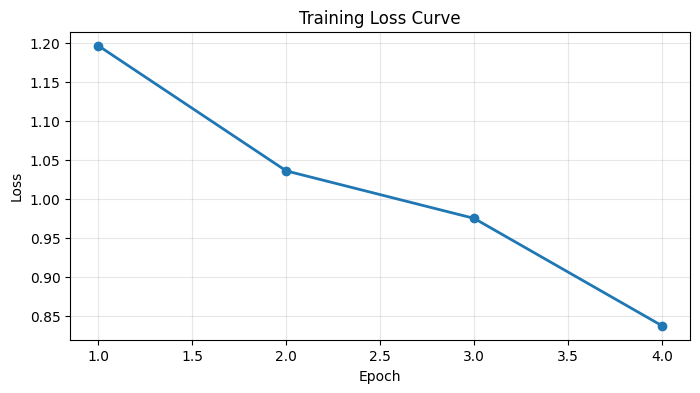

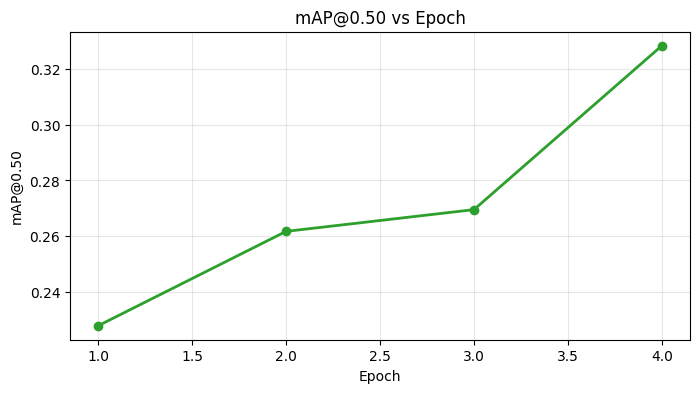

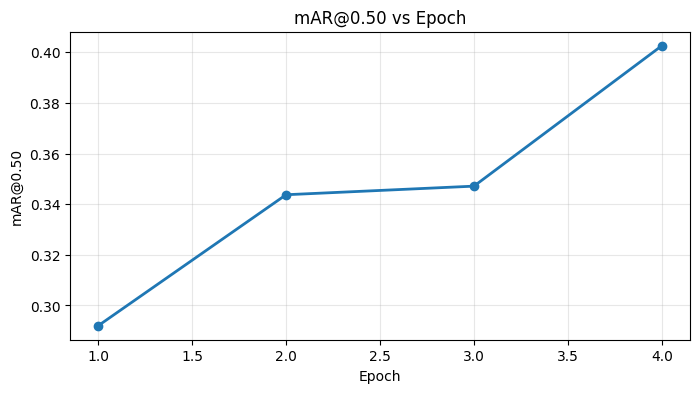

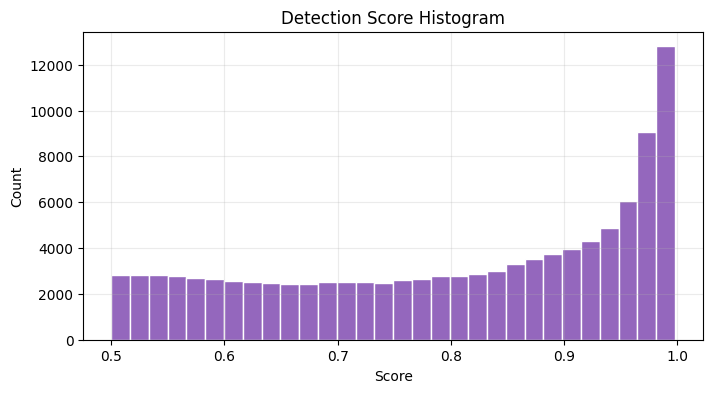

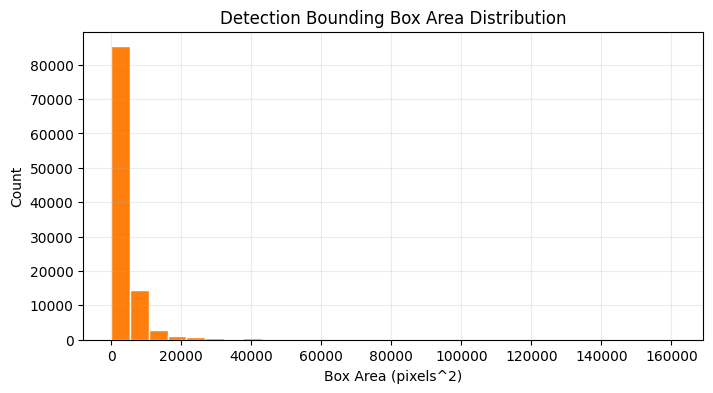

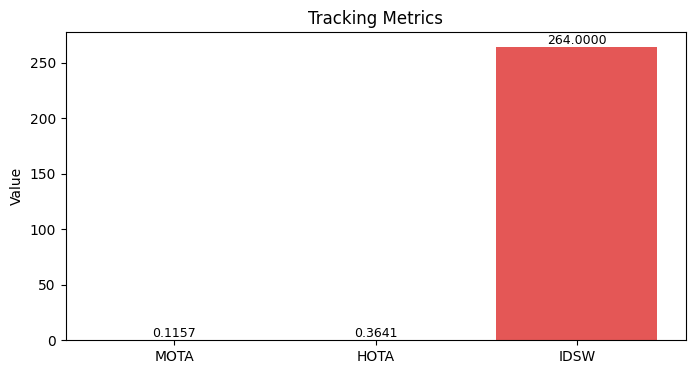

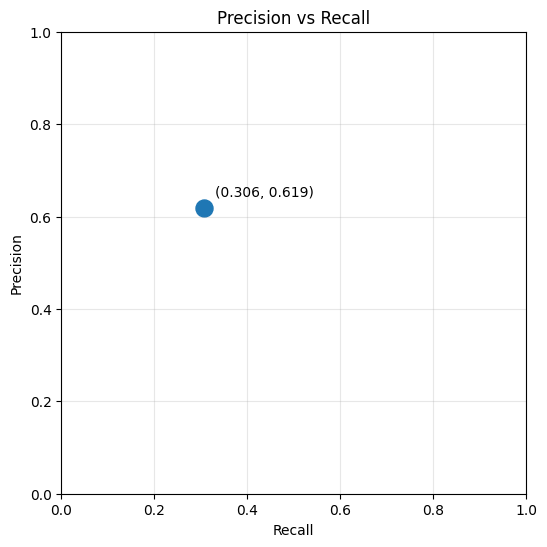

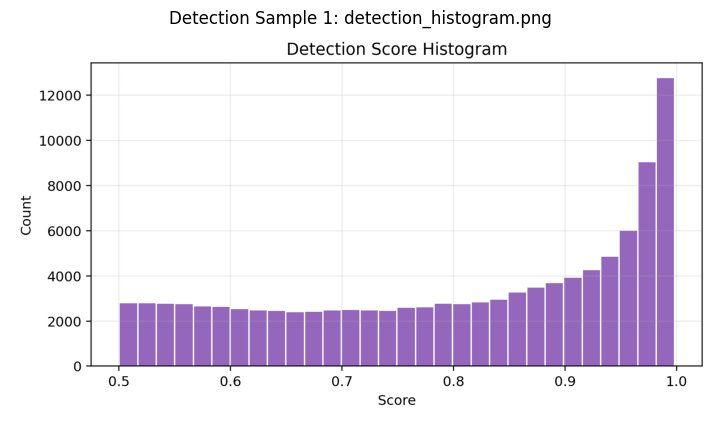

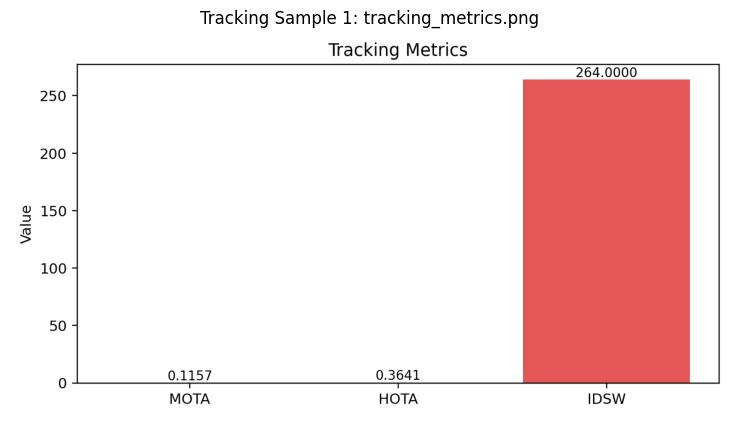

Generated plot files: ['loss_curve.png', 'map_curve.png', 'mar_curve.png', 'detection_histogram.png', 'bbox_area_distribution.png', 'tracking_metrics.png', 'precision_recall.png']
All visualizations generated and saved in artifacts/reports


In [ ]:
# =============================================================
# VISUALIZATION RE-RUN (ANALYSIS ONLY)
# This block regenerates plots and visual summaries from saved artifacts.
# It does not retrain models or recompute detector weights.
# The purpose is reporting/inspection after successful metric generation.
# =============================================================

#Special  Visualization cell: Plot curves and graphs (Explicit run to save image's as earlier result's were truncated due to session issue))

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

reports_dir = Path('/kaggle/working/artifacts/reports')
reports_dir.mkdir(parents=True, exist_ok=True)

artifacts_dir = Path('/kaggle/working/artifacts')
detector_dir = artifacts_dir / 'detector'
mot_dir = artifacts_dir / 'mot'

history_path = detector_dir / 'train_history.json'
summary_path = artifacts_dir / 'metrics_summary.json'
tracking_metrics_path = mot_dir / 'tracking_metrics.json'
detections_dir = mot_dir / 'detections'

history = []
summary = {}
tracking_metrics = {}

if history_path.exists():
    history = json.loads(history_path.read_text(encoding='utf-8'))
else:
    print(f'[warn] Missing training history: {history_path}')

if summary_path.exists():
    summary = json.loads(summary_path.read_text(encoding='utf-8'))
else:
    print(f'[warn] Missing metrics summary: {summary_path}')

if tracking_metrics_path.exists():
    tracking_metrics = json.loads(tracking_metrics_path.read_text(encoding='utf-8'))
elif 'tracking_overall' in summary:
    tracking_metrics = {'overall': summary.get('tracking_overall', {})}
else:
    print(f'[warn] Missing tracking metrics: {tracking_metrics_path}')

generated_plots = []

def save_and_show(fig, out_path: Path):
    fig.savefig(out_path, dpi=220, bbox_inches='tight')
    generated_plots.append(out_path.name)
    plt.show()
    plt.close(fig)

# 1) Training Loss Curve, 2) mAP@0.50, 3) mAR@0.50
if history:
    epochs = [int(item.get('epoch', idx + 1)) for idx, item in enumerate(history)]
    losses = [float(item.get('train_loss', 0.0)) for item in history]
    map50 = [float(item.get('val_metrics', {}).get('mAP@0.50', 0.0)) for item in history]
    mar50 = [float(item.get('val_metrics', {}).get('mAR@0.50', 0.0)) for item in history]

    fig = plt.figure(figsize=(8, 4))
    plt.plot(epochs, losses, marker='o', linewidth=2)
    plt.title('Training Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    save_and_show(fig, reports_dir / 'loss_curve.png')

    fig = plt.figure(figsize=(8, 4))
    plt.plot(epochs, map50, marker='o', linewidth=2, color='#2ca02c')
    plt.title('mAP@0.50 vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('mAP@0.50')
    plt.grid(alpha=0.3)
    save_and_show(fig, reports_dir / 'map_curve.png')

    fig = plt.figure(figsize=(8, 4))
    plt.plot(epochs, mar50, marker='o', linewidth=2, color='#1f77b4')
    plt.title('mAR@0.50 vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('mAR@0.50')
    plt.grid(alpha=0.3)
    save_and_show(fig, reports_dir / 'mar_curve.png')
else:
    print('[info] Training plots skipped: train_history.json not available or empty.')

# 4) Detection analysis from artifacts/mot/detections
scores = []
bbox_areas = []
if detections_dir.exists():
    det_files = sorted(detections_dir.glob('*.txt'))[:20]
    for txt_file in det_files:
        for line in txt_file.read_text(encoding='utf-8').splitlines():
            parts = [p.strip() for p in line.split(',')]
            if len(parts) < 7:
                continue
            try:
                w = float(parts[4])
                h = float(parts[5])
                score = float(parts[6])
            except ValueError:
                continue
            if w > 0 and h > 0:
                bbox_areas.append(w * h)
            scores.append(score)

if scores:
    fig = plt.figure(figsize=(8, 4))
    plt.hist(scores, bins=30, color='#9467bd', edgecolor='white')
    plt.title('Detection Score Histogram')
    plt.xlabel('Score')
    plt.ylabel('Count')
    plt.grid(alpha=0.25)
    save_and_show(fig, reports_dir / 'detection_histogram.png')
else:
    print('[info] Detection score histogram skipped: no detection scores found.')

if bbox_areas:
    fig = plt.figure(figsize=(8, 4))
    plt.hist(bbox_areas, bins=30, color='#ff7f0e', edgecolor='white')
    plt.title('Detection Bounding Box Area Distribution')
    plt.xlabel('Box Area (pixels^2)')
    plt.ylabel('Count')
    plt.grid(alpha=0.25)
    save_and_show(fig, reports_dir / 'bbox_area_distribution.png')
else:
    print('[info] Bounding box area plot skipped: no valid detection boxes found.')

# 5) Tracking analysis from tracking_metrics.json
overall = (tracking_metrics or {}).get('overall', {})
if overall:
    mota = float(overall.get('MOTA', 0.0))
    hota = float(overall.get('HOTA', 0.0))
    idsw = float(overall.get('IDSW', 0.0))
    precision = float(overall.get('precision', 0.0))
    recall = float(overall.get('recall', 0.0))

    fig = plt.figure(figsize=(8, 4))
    labels = ['MOTA', 'HOTA', 'IDSW']
    values = [mota, hota, idsw]
    colors = ['#72b7b2', '#b279a2', '#e45756']
    bars = plt.bar(labels, values, color=colors)
    plt.title('Tracking Metrics')
    plt.ylabel('Value')
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.4f}', ha='center', va='bottom', fontsize=9)
    save_and_show(fig, reports_dir / 'tracking_metrics.png')

    fig = plt.figure(figsize=(6, 6))
    plt.scatter([recall], [precision], s=150, color='#1f77b4')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision vs Recall')
    plt.grid(alpha=0.3)
    plt.annotate(f'({recall:.3f}, {precision:.3f})', (recall, precision), textcoords='offset points', xytext=(8, 8))
    save_and_show(fig, reports_dir / 'precision_recall.png')
else:
    print('[info] Tracking plots skipped: tracking_metrics.json overall metrics not found.')

# 6) Visual samples from existing report images (if available)
def show_image_samples(paths, title_prefix, max_items=5):
    if not paths:
        print(f'[info] No {title_prefix.lower()} images found to display.')
        return
    for i, image_path in enumerate(paths[:max_items], start=1):
        try:
            img = Image.open(image_path).convert('RGB')
        except Exception as exc:
            print(f'[warn] Could not open image {image_path}: {exc}')
            continue
        fig = plt.figure(figsize=(10, 5))
        plt.imshow(np.asarray(img))
        plt.title(f'{title_prefix} {i}: {image_path.name}')
        plt.axis('off')
        plt.show()
        plt.close(fig)

detection_sample_images = sorted(reports_dir.glob('detection_samples_*.png'))
if not detection_sample_images:
    detection_sample_images = sorted(reports_dir.glob('detection*.png'))

tracking_sample_images = sorted(reports_dir.glob('tracking_samples_*.png'))
if not tracking_sample_images:
    tracking_sample_images = sorted(reports_dir.glob('tracking*.png'))

show_image_samples(detection_sample_images, 'Detection Sample', max_items=5)
show_image_samples(tracking_sample_images, 'Tracking Sample', max_items=5)

print('Generated plot files:', generated_plots)
print('All visualizations generated and saved in artifacts/reports')

---

## Additional Qualitative Diagnostics

The following cell extends qualitative analysis and visual diagnostics for detection/tracking behavior.
It uses generated artifacts and does not modify model parameters or metrics.

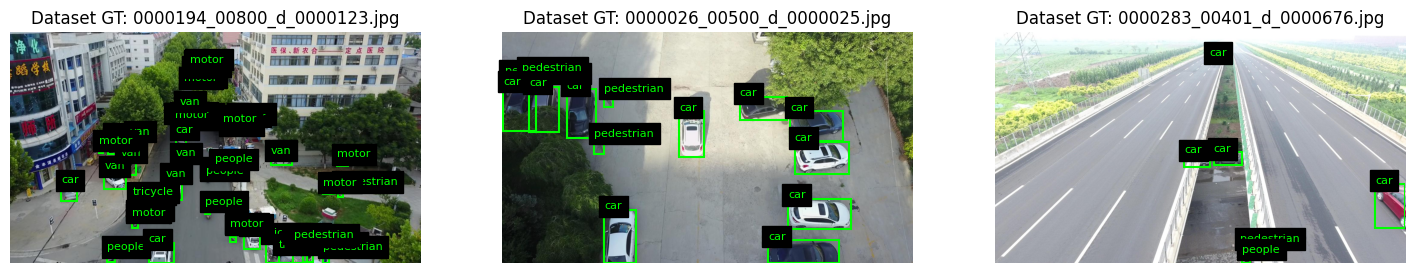

[saved] /kaggle/working/artifacts/reports/dataset_samples.png
Using detection checkpoint: /kaggle/working/artifacts/detector/detector_epoch_004.pth


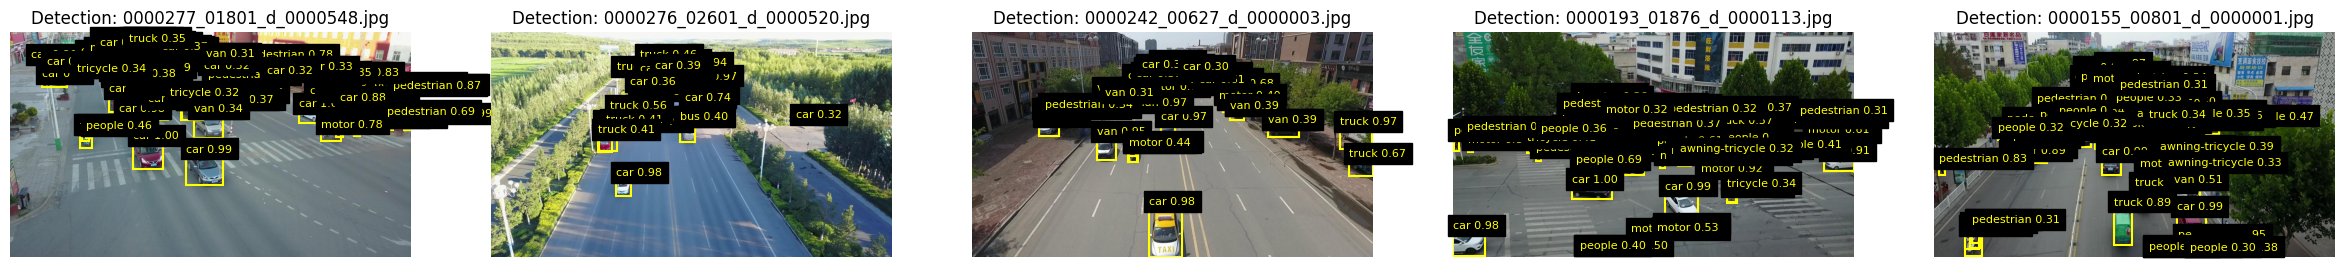

[saved] /kaggle/working/artifacts/reports/detection_samples.png


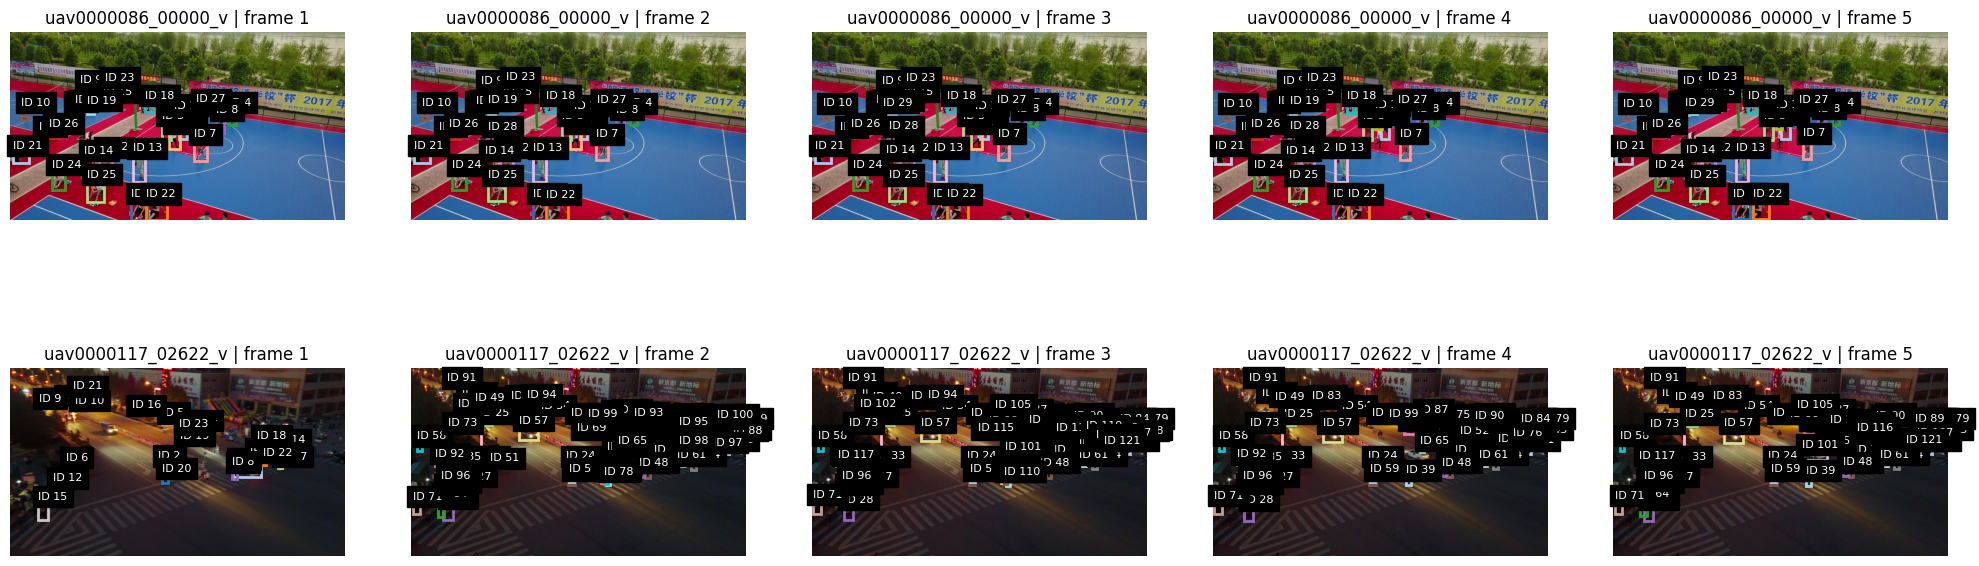

[saved] /kaggle/working/artifacts/reports/tracking_samples.png


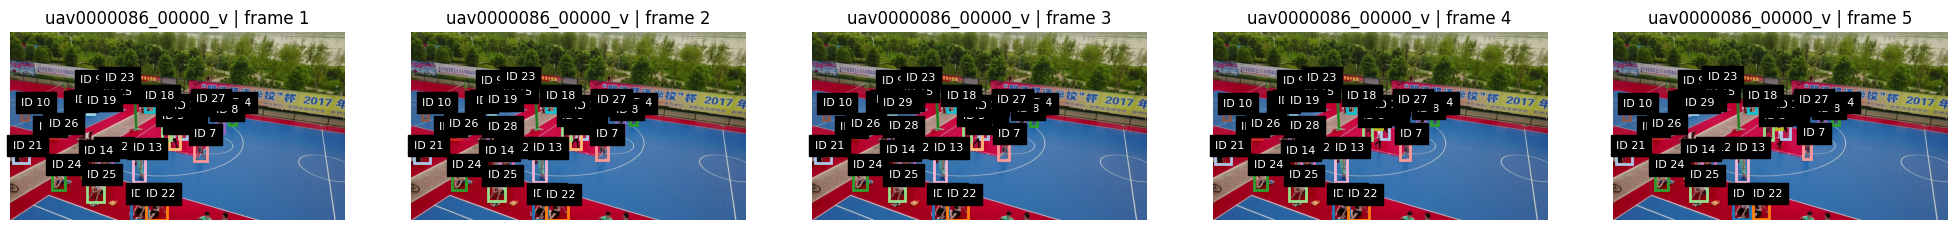

[saved] /kaggle/working/artifacts/reports/tracking_sequence_grid.png
All visual images generated and saved in reports directory


In [55]:
# FINAL visualization section: real image-based qualitative outputs (no training rerun)
from pathlib import Path
import random
from collections import defaultdict
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

reports_dir = Path('/kaggle/working/artifacts/reports')
reports_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Helpers
# -----------------------------
def _resolve_det_root_for_vis(path: Path) -> Path:
    current = path
    for _ in range(6):
        if (current / 'images').exists() and (current / 'annotations').exists():
            return current
        if not current.exists() or not current.is_dir():
            break
        subdirs = [d for d in current.iterdir() if d.is_dir()]
        if len(subdirs) == 1:
            current = subdirs[0]
        else:
            break
    return current

def _resolve_mot_root_for_vis(path: Path) -> Path:
    # Prefer existing helper if available.
    if '_resolve_mot_root' in globals():
        try:
            return _resolve_mot_root(path)
        except Exception:
            pass

    current = path
    for _ in range(6):
        if (current / 'sequences').exists():
            return current
        if not current.exists() or not current.is_dir():
            break
        subdirs = [d for d in current.iterdir() if d.is_dir()]
        if len(subdirs) == 1:
            current = subdirs[0]
        else:
            break
    return current

def _read_visdrone_gt(ann_path: Path):
    gt_boxes = []
    if not ann_path.exists():
        return gt_boxes
    for line in ann_path.read_text(encoding='utf-8').splitlines():
        parts = [p.strip() for p in line.split(',')]
        if len(parts) < 6:
            continue
        try:
            x, y, w, h = map(float, parts[:4])
            score = float(parts[4])
            cls_id = int(float(parts[5]))
        except ValueError:
            continue
        if w <= 0 or h <= 0:
            continue
        if cls_id < 1 or cls_id > 10:
            continue
        # Keep only valid foreground GT.
        if score <= 0:
            continue
        gt_boxes.append((x, y, w, h, cls_id))
    return gt_boxes

def _class_name_local(cls_id: int) -> str:
    fallback = {
        1: 'pedestrian', 2: 'people', 3: 'bicycle', 4: 'car', 5: 'van',
        6: 'truck', 7: 'tricycle', 8: 'awning-tricycle', 9: 'bus', 10: 'motor'
    }
    if 'VISDRONE_CLASS_NAMES' in globals():
        return VISDRONE_CLASS_NAMES.get(int(cls_id), f'class-{int(cls_id)}')
    return fallback.get(int(cls_id), f'class-{int(cls_id)}')

def _save_show(fig, out_path: Path):
    fig.savefig(out_path, dpi=220, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'[saved] {out_path}')

# -----------------------------
# STEP 2: Dataset sample visualization (GT boxes)
# -----------------------------
det_val_root = _resolve_det_root_for_vis(Path(DET_VAL_DIR))
det_val_images = det_val_root / 'images'
det_val_annotations = det_val_root / 'annotations'
assert det_val_images.exists(), f'Validation images not found: {det_val_images}'
assert det_val_annotations.exists(), f'Validation annotations not found: {det_val_annotations}'

img_paths = sorted([p for p in det_val_images.iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}])
if not img_paths:
    raise FileNotFoundError(f'No validation images found in: {det_val_images}')

random.seed(42)
dataset_samples = random.sample(img_paths, k=min(3, len(img_paths)))

fig, axes = plt.subplots(1, len(dataset_samples), figsize=(6 * len(dataset_samples), 5))
if len(dataset_samples) == 1:
    axes = [axes]

for ax, img_path in zip(axes, dataset_samples):
    img = Image.open(img_path).convert('RGB')
    arr = np.asarray(img)
    ax.imshow(arr)
    ann_path = det_val_annotations / f'{img_path.stem}.txt'
    for x, y, w, h, cls_id in _read_visdrone_gt(ann_path):
        rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, max(0, y - 2), _class_name_local(cls_id), color='lime', fontsize=8, backgroundcolor='black')
    ax.set_title(f'Dataset GT: {img_path.name}')
    ax.axis('off')

_save_show(fig, reports_dir / 'dataset_samples.png')

# -----------------------------
# STEP 3: Detection visualization (predictions)
# -----------------------------
detector_dir = Path('/kaggle/working/artifacts/detector')
if not detector_dir.exists():
    raise FileNotFoundError(f'Detector directory not found: {detector_dir}')

ckpts = sorted(detector_dir.glob('*.pth'), key=lambda p: p.stat().st_mtime)
if not ckpts:
    raise FileNotFoundError(f'No detector checkpoint found in: {detector_dir}')
latest_ckpt = ckpts[-1]
print('Using detection checkpoint:', latest_ckpt)

device = DEVICE if 'DEVICE' in globals() else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = get_model(num_object_classes=10, pretrained=False).to(device)
if '_configure_model_for_runtime' in globals():
    model = _configure_model_for_runtime(model)
ckpt = torch.load(latest_ckpt, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

det_samples = random.sample(img_paths, k=min(5, len(img_paths)))
fig, axes = plt.subplots(1, len(det_samples), figsize=(6 * len(det_samples), 5))
if len(det_samples) == 1:
    axes = [axes]

with torch.no_grad():
    for ax, img_path in zip(axes, det_samples):
        img = Image.open(img_path).convert('RGB')
        arr = np.asarray(img)
        tensor = F.to_tensor(img).to(device) if 'F' in globals() else torch.from_numpy(arr).permute(2, 0, 1).float().div(255).to(device)
        out = model([tensor])[0]
        boxes = out['boxes'].detach().cpu().numpy() if 'boxes' in out else np.empty((0, 4))
        scores = out['scores'].detach().cpu().numpy() if 'scores' in out else np.empty((0,))
        labels = out['labels'].detach().cpu().numpy() if 'labels' in out else np.empty((0,))

        ax.imshow(arr)
        keep = scores >= 0.3
        for box, score, label in zip(boxes[keep], scores[keep], labels[keep]):
            x1, y1, x2, y2 = [float(v) for v in box.tolist()]
            w = max(0.0, x2 - x1)
            h = max(0.0, y2 - y1)
            if w <= 0 or h <= 0:
                continue
            rect = patches.Rectangle((x1, y1), w, h, linewidth=1.5, edgecolor='yellow', facecolor='none')
            ax.add_patch(rect)
            name = _class_name_local(int(label))
            ax.text(x1, max(0, y1 - 2), f'{name} {float(score):.2f}', color='yellow', fontsize=8, backgroundcolor='black')

        ax.set_title(f'Detection: {img_path.name}')
        ax.axis('off')

_save_show(fig, reports_dir / 'detection_samples.png')

# -----------------------------
# STEP 4 + 5: Tracking visualization + sequence grid
# -----------------------------
mot_root = _resolve_mot_root_for_vis(Path(MOT_VAL_DIR))
sequences_root = mot_root / 'sequences'
tracks_root = Path('/kaggle/working/artifacts/mot/tracks')
assert sequences_root.exists(), f'MOT sequences folder not found: {sequences_root}'
assert tracks_root.exists(), f'Tracks folder not found: {tracks_root}'

track_files = sorted(tracks_root.glob('*.txt'))
if not track_files:
    raise FileNotFoundError(f'No tracking files found in: {tracks_root}')

selected_track_files = track_files[:2]
tracking_panels = []

def _color_for_id(track_id: int):
    cmap = plt.get_cmap('tab20')
    return cmap(int(track_id) % 20)

for track_file in selected_track_files:
    seq_name = track_file.stem
    seq_dir = sequences_root / seq_name
    frame_dir = seq_dir / 'img1' if (seq_dir / 'img1').exists() else seq_dir
    if not frame_dir.exists():
        print(f'[warn] Sequence frames missing for {seq_name}, skipping.')
        continue

    frame_paths = sorted([p for p in frame_dir.iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}])
    if not frame_paths:
        print(f'[warn] No frames found for {seq_name}, skipping.')
        continue

    tracks_by_frame = defaultdict(list)
    for line in track_file.read_text(encoding='utf-8').splitlines():
        parts = [p.strip() for p in line.split(',')]
        if len(parts) < 6:
            continue
        try:
            frame_id = int(float(parts[0]))
            tid = int(float(parts[1]))
            x = float(parts[2]); y = float(parts[3]); w = float(parts[4]); h = float(parts[5])
        except ValueError:
            continue
        if w <= 0 or h <= 0:
            continue
        tracks_by_frame[frame_id].append((tid, x, y, w, h))

    frame_map = {}
    for p in frame_paths:
        stem = p.stem
        try:
            fid = int(stem) if stem.isdigit() else int(''.join(ch for ch in stem if ch.isdigit()))
        except ValueError:
            continue
        frame_map[fid] = p

    chosen_frame_ids = sorted([fid for fid in tracks_by_frame.keys() if fid in frame_map])[:5]
    if not chosen_frame_ids:
        chosen_frame_ids = sorted(frame_map.keys())[:5]

    for fid in chosen_frame_ids:
        img_path = frame_map[fid]
        img = Image.open(img_path).convert('RGB')
        arr = np.asarray(img)
        tracking_panels.append((seq_name, fid, arr, tracks_by_frame.get(fid, [])))

if not tracking_panels:
    raise RuntimeError('Could not build tracking visualization panels from available tracks and frames.')

# tracking_samples.png (up to 10 panels = 2 seq x 5 frames)
n = len(tracking_panels)
cols = min(5, n)
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.array(axes).reshape(-1) if isinstance(axes, np.ndarray) else [axes]

for ax, panel in zip(axes, tracking_panels):
    seq_name, fid, arr, tracks = panel
    ax.imshow(arr)
    for tid, x, y, w, h in tracks:
        color = _color_for_id(tid)
        rect = patches.Rectangle((x, y), w, h, linewidth=2.0, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x, max(0, y - 2), f'ID {tid}', color='white', fontsize=8, backgroundcolor='black')
    ax.set_title(f'{seq_name} | frame {fid}')
    ax.axis('off')

for ax in axes[len(tracking_panels):]:
    ax.axis('off')

_save_show(fig, reports_dir / 'tracking_samples.png')

# tracking_sequence_grid.png (video-like movement for first sequence only)
first_seq = tracking_panels[0][0]
first_seq_panels = [p for p in tracking_panels if p[0] == first_seq][:5]
fig, axes = plt.subplots(1, len(first_seq_panels), figsize=(5 * len(first_seq_panels), 4))
if len(first_seq_panels) == 1:
    axes = [axes]

for ax, panel in zip(axes, first_seq_panels):
    _, fid, arr, tracks = panel
    ax.imshow(arr)
    for tid, x, y, w, h in tracks:
        color = _color_for_id(tid)
        rect = patches.Rectangle((x, y), w, h, linewidth=2.0, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x, max(0, y - 2), f'ID {tid}', color='white', fontsize=8, backgroundcolor='black')
    ax.set_title(f'{first_seq} | frame {fid}')
    ax.axis('off')

_save_show(fig, reports_dir / 'tracking_sequence_grid.png')

print('All visual images generated and saved in reports directory')

## 13. Limitations

The current pipeline is intentionally simple and reproducible, which introduces known performance constraints:
- No ReID module: identity continuity relies only on geometry and confidence, increasing ID switches under occlusion.
- IoU-only association: limited robustness to abrupt motion, scale jumps, and long-term re-appearance.
- Limited detector training budget (4 epochs): likely underfits hard aerial cases, especially tiny or heavily occluded objects.
- Small-object difficulty in aerial imagery: reduced pixel support lowers both localization quality and recall.

## 14. Future Improvements

Practical next steps to improve performance while preserving reproducibility:
- Add an appearance-based ReID branch for stronger identity persistence through occlusions.
- Increase training epochs with systematic early stopping and validation monitoring.
- Perform structured hyperparameter tuning for confidence and association thresholds.
- Evaluate stronger detectors (for example, modern YOLO variants or transformer-based detectors) for small-object recall gains.
- Incorporate stronger motion modeling and track management for crowded, fast-changing scenes.

## 15. Conclusion

This notebook presents a complete, reproducible tracking-by-detection pipeline tailored to VisDrone constraints.
The analysis shows a clear pattern: detector miss rate and identity continuity are the dominant bottlenecks, while the current setup maintains reasonable precision.
Overall, the pipeline is a solid baseline for evaluation and can be incrementally strengthened with ReID, richer motion cues, and deeper detector optimization.

Transition: the optional appendix below contains demo-only utilities and does not alter the core evaluation results.

## Appendix: Demo Mode (Optional)

This optional section runs a short qualitative demo for presentation use.
It is runtime-bounded and separated from the main evaluation flow to avoid affecting core results.

In [ ]:
# Appendix: quick review helper

def run_quick_review_mode(
    epochs: int = 1,
    batch_size: int = 2,
    num_workers: int = 2,
    lr: float = 0.005,
    det_score_thresh: float = DET_SCORE_THRESH,
    mot_score_thresh: float = MOT_SCORE_THRESH,
    max_frames: int = 200,
    run_tracking_eval: bool = True,
    skip_if_exists: bool = True,
) -> Dict[str, object]:
    """Run a short, reviewer-friendly pipeline pass without changing the main auto flow."""
    results: Dict[str, object] = {}

    _ensure_stage_paths(
        'quick_review_setup',
        {
            'DET_TRAIN_DIR': DET_TRAIN_DIR,
            'DET_VAL_DIR': DET_VAL_DIR,
            'MOT_VAL_DIR': MOT_VAL_DIR,
        },
    )

    print('Quick Review Mode')
    print('This mode is separate from run_full_pipeline().')

    conversion_stats = convert_stage(skip_if_exists=skip_if_exists, log_every=LOG_EVERY)
    results['conversion'] = conversion_stats

    ckpt_path = train_stage(
        epochs=epochs,
        batch_size=batch_size,
        num_workers=num_workers,
        lr=lr,
        det_score_thresh=det_score_thresh,
        resume_if_available=True,
    )
    results['checkpoint'] = str(ckpt_path)

    det_metrics = evaluate_detector_stage(
        checkpoint_path=Path(ckpt_path),
        batch_size=batch_size,
        num_workers=num_workers,
        det_score_thresh=det_score_thresh,
    )
    results['det_metrics'] = det_metrics

    mot_summary = run_mot_infer_stage(
        checkpoint_path=Path(ckpt_path),
        mot_score_thresh=mot_score_thresh,
        max_frames=max_frames,
        skip_if_exists=skip_if_exists,
        assoc_min_score=TRACK_ASSOC_MIN_SCORE,
    )
    results['mot_summary'] = mot_summary

    if run_tracking_eval:
        track_metrics = evaluate_tracking_stage(iou_threshold=0.5, class_aware=True)
        results['track_metrics'] = track_metrics

    manifest_path = write_manifest(Path(ckpt_path))
    results['manifest'] = str(manifest_path)

    print('Quick review completed.')
    print('Manifest:', manifest_path)
    return results

In [ ]:
# Appendix: prompt-driven demo (non-blocking)

RUN_DEMO = False


def run_demo_mode(max_runtime_seconds: int = 300) -> None:
    if not RUN_DEMO:
        print('Demo skipped (RUN_DEMO=False).')
        return

    start = time.time()
    ckpt_path, _ = find_latest_checkpoint()
    if ckpt_path is None:
        print('Demo skipped: no checkpoint found for detection visualization.')
        return

    print('Running demo: detection visualization (8 images).')
    visualize_detection_samples(ckpt_path, num_samples=8, score_thresh=DET_SCORE_THRESH)

    if time.time() - start > max_runtime_seconds:
        print(f'Demo time budget reached ({max_runtime_seconds}s). Stopping early.')
        return

    if _has_tracking_outputs():
        print('Running demo: tracking visualization (up to 2 sequences).')
        visualize_tracking_samples(num_frames=3, max_sequences=2)
    else:
        print('Demo tracking skipped: tracking outputs are not available.')

    elapsed = time.time() - start
    print(f'Demo completed in {elapsed:.1f}s.')


# Example usage (run manually when needed):
# RUN_DEMO = True
# run_demo_mode(max_runtime_seconds=300)

run_demo_mode(max_runtime_seconds=300)